AI-Driven CRM Analytics: Predictive Churn Modelling and Retention Strategy Optimisation in Telecommunications

Author: Rishit Arora | MSc Business Analytics | 25239324  
Module: MS5131 Major Business Analytics Project  
University of Galway

---

In [2]:
!pip install xgboost
!pip install shap
!pip install imbalanced-learn

1: Setup & Imports


In [3]:
# Core libraries
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Clean, professional plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12


import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully")

✅ All libraries loaded successfully


Loading our dataset

In [4]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nData types:\n")
print(df.dtypes)
print(f"\n{'='*50}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: 7043 rows × 21 columns

Data types:

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Data is loaded. It results in 70430 rows and 21 columns. 

Data Inspection

In [5]:
# Initial Data Inspection
# Let's understand what we're working with
print("DATA TYPES")
print("="*50)
print(df.dtypes)

DATA TYPES
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [6]:
# Checking for Missing & Incorrect Values
# Check for null values across all columns
print("NULL VALUES PER COLUMN")
print("="*50)
print(df.isnull().sum())
print(f"\nTotal nulls: {df.isnull().sum().sum()}")

NULL VALUES PER COLUMN
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total nulls: 0


In [7]:
# Investigating Data Types
# I noticed TotalCharges shows as 'object' (text) when exploring datatypes
# but it should be numeric.

df['TotalCharges_test'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Rows that failed the conversion- 
problem_rows = df[df['TotalCharges_test'].isnull()]
print(f"Rows that couldn't convert to numeric: {len(problem_rows)}")
print(f"\nLet's look at them:")
print(problem_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']])

# Cleaning up test column
df.drop('TotalCharges_test', axis=1, inplace=True)

Rows that couldn't convert to numeric: 11

Let's look at them:
      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00                 No
5218  2923-ARZLG       0           19.70                 No
6670  4075-WKNIU       0           73.35                 No
6754  2775-SEFEE       0           61.90                 No


Data Cleaning

In [8]:
# FINDINGS: 11 rows have blank TotalCharges and all have tenure = 0.
# This implies that these are brand new customers who haven't been billed yet.
# 
# Decision : Conversion of TotalCharges to numeric dattype and fillthe blanks with 0,
# since these customers genuinely have zero charges so far.

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)

# Creating a binary target variable for modelling since churn column has 'Yes'/'No' — we need 1/0 for
# classification models that will follow
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

# Verifying everything is clean
print("POST-CLEANING CHECKS")
print("="*50)
print(f"TotalCharges dtype: {df['TotalCharges'].dtype}")
print(f"Remaining nulls:    {df.isnull().sum().sum()}")
print(f"Dataset shape:      {df.shape}")
print(f"\nChurn distribution:")
print(df['Churn_binary'].value_counts())
print(f"\nChurn rate: {df['Churn_binary'].mean()*100:.1f}%")

POST-CLEANING CHECKS
TotalCharges dtype: float64
Remaining nulls:    0
Dataset shape:      (7043, 22)

Churn distribution:
Churn_binary
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 26.5%


 Dataset Summary Statistics

In [9]:
# Now that our dataset is clean, and modified let's understand the distributions
# of our numeric variables

print("SUMMARY STATISTICS — NUMERIC COLUMNS")
print("="*60)
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2))

print("\n\nKEY OBSERVATIONS:")
print("-"*60)
print(f"• Tenure ranges from 0 to {df['tenure'].max()} months ({df['tenure'].max()/12:.1f} years)")
print(f"• Average customer has been with the company {df['tenure'].mean():.0f} months")
print(f"• Monthly charges range from €{df['MonthlyCharges'].min():.2f} to €{df['MonthlyCharges'].max():.2f}")
print(f"• Average monthly bill: €{df['MonthlyCharges'].mean():.2f}")

SUMMARY STATISTICS — NUMERIC COLUMNS
        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7043.00
mean     32.37           64.76       2279.73
std      24.56           30.09       2266.79
min       0.00           18.25          0.00
25%       9.00           35.50        398.55
50%      29.00           70.35       1394.55
75%      55.00           89.85       3786.60
max      72.00          118.75       8684.80


KEY OBSERVATIONS:
------------------------------------------------------------
• Tenure ranges from 0 to 72 months (6.0 years)
• Average customer has been with the company 32 months
• Monthly charges range from €18.25 to €118.75
• Average monthly bill: €64.76


Category-based variable overview 

In [10]:
# Breakdown of each categorical variable to understand customer base in the dataset

cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 
            'PhoneService', 'InternetService', 'Contract', 
            'PaperlessBilling', 'PaymentMethod']

for col in cat_cols:
    print(f"\n{col.upper()}")
    print("-" * 40)
    counts = df[col].value_counts()
    for val, count in counts.items():
        pct = count / len(df) * 100
        print(f"  {str(val):30s} {count:5d}  ({pct:.1f}%)")


GENDER
----------------------------------------
  Male                            3555  (50.5%)
  Female                          3488  (49.5%)

SENIORCITIZEN
----------------------------------------
  0                               5901  (83.8%)
  1                               1142  (16.2%)

PARTNER
----------------------------------------
  No                              3641  (51.7%)
  Yes                             3402  (48.3%)

DEPENDENTS
----------------------------------------
  No                              4933  (70.0%)
  Yes                             2110  (30.0%)

PHONESERVICE
----------------------------------------
  Yes                             6361  (90.3%)
  No                               682  (9.7%)

INTERNETSERVICE
----------------------------------------
  Fiber optic                     3096  (44.0%)
  DSL                             2421  (34.4%)
  No                              1526  (21.7%)

CONTRACT
----------------------------------------
  Mon

Data Visualisation - Churn distribution

Shall observe churn rate of customers based on various factors

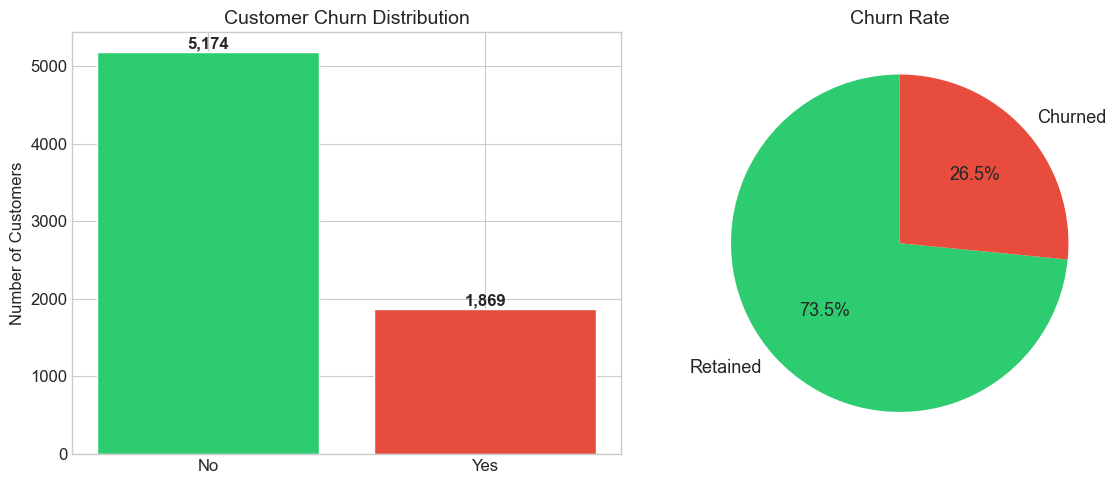

📊 Figure saved as 'fig1_churn_distribution.png'

The dataset is imbalanced — only 26.5% of customers churned.
This imbalance will need to be addressed during modelling (SMOTE).


In [11]:
# seeing the overall picture to get an overview

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Count of churned vs retained
colors = ['#2ecc71', '#e74c3c']
churn_counts = df['Churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Customer Churn Distribution')
axes[0].set_ylabel('Number of Customers')

# Adding count labels on bars
for i, (val, count) in enumerate(zip(churn_counts.index, churn_counts.values)):
    axes[0].text(i, count + 50, f'{count:,}', ha='center', fontweight='bold')

# Plot 2: Percentage view
axes[1].pie(churn_counts.values, labels=['Retained', 'Churned'], 
            colors=colors, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 13})
axes[1].set_title('Churn Rate')

plt.tight_layout()
plt.savefig('fig1_churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("📊 Figure saved as 'fig1_churn_distribution.png'")
print(f"\nThe dataset is imbalanced — only 26.5% of customers churned.")
print(f"This imbalance will need to be addressed during modelling (SMOTE).")

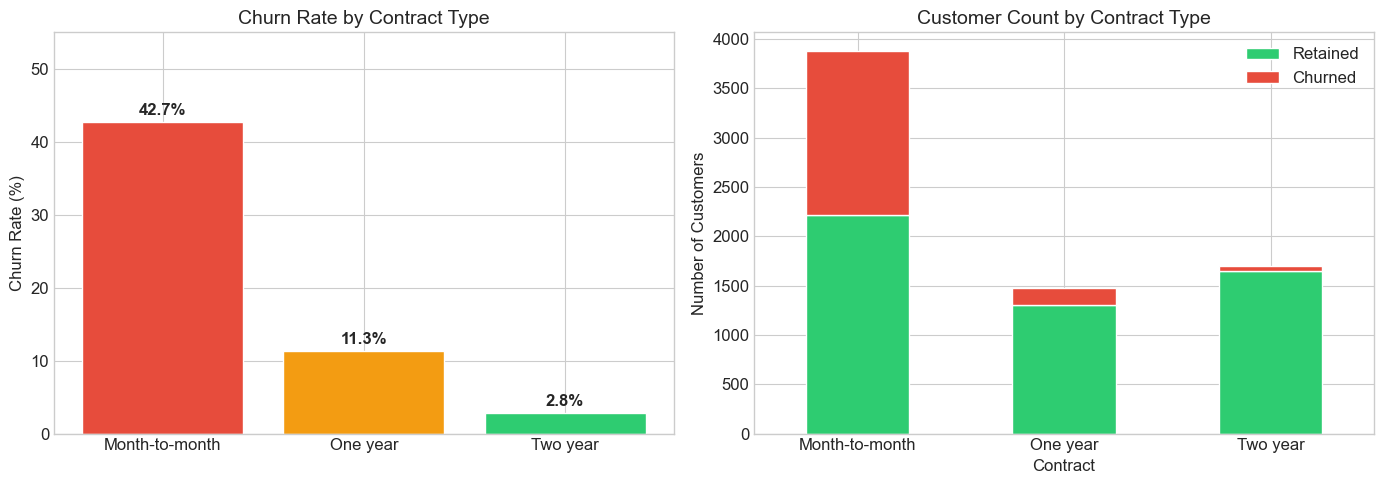

📊 Figure saved as 'fig2_churn_by_contract.png'

KEY FINDING:
Month-to-month customers churn at 42.7% — 15x higher than two-year contracts (2.8%).
This makes business sense: no contract = no switching cost = easy to leave.


In [12]:
# Churn rate as per a customers contract type
# Chose "Contract type", as it seems like an obvious affecting factor 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Churn rate by contract type
contract_churn = df.groupby('Contract')['Churn_binary'].mean() * 100
contract_order = ['Month-to-month', 'One year', 'Two year']
contract_churn = contract_churn.reindex(contract_order)

bars = axes[0].bar(contract_churn.index, contract_churn.values, 
                    color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white')
axes[0].set_title('Churn Rate by Contract Type')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 55)

# Adding percentage labels
for bar, val in zip(bars, contract_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                 f'{val:.1f}%', ha='center', fontweight='bold')

# Plot 2: Count of customers by contract type and then split by churn
contract_data = df.groupby(['Contract', 'Churn']).size().unstack()
contract_data = contract_data.reindex(contract_order)
contract_data.plot(kind='bar', stacked=True, ax=axes[1], 
                    color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[1].set_title('Customer Count by Contract Type')
axes[1].set_ylabel('Number of Customers')
axes[1].set_xticklabels(contract_order, rotation=0)
axes[1].legend(['Retained', 'Churned'])

plt.tight_layout()
plt.savefig('fig2_churn_by_contract.png', dpi=300, bbox_inches='tight')
plt.show()

print("📊 Figure saved as 'fig2_churn_by_contract.png'")
print(f"\nKEY FINDING:")
print(f"Month-to-month customers churn at 42.7% — 15x higher than two-year contracts (2.8%).")
print(f"This makes business sense: no contract = no switching cost = easy to leave.")

In [13]:
# Exploring Key Segments with SQL
# Using SQL queries to explore churn patterns across segments as it is 
# useful for quick aggregations and filtering

import sqlite3

# Loading my dataframe into a temporary SQL database
conn = sqlite3.connect(':memory:')
df.to_sql('customers', conn, index=False, if_exists='replace')

# Query 1: Average monthly charges by churn status and contract type
query1 = """
    SELECT Contract, Churn,
           COUNT(*) as customer_count,
           ROUND(AVG(MonthlyCharges), 2) as avg_monthly_charge,
           ROUND(AVG(tenure), 1) as avg_tenure
    FROM customers
    GROUP BY Contract, Churn
    ORDER BY Contract, Churn
"""
print("CHURN PROFILE BY CONTRACT TYPE")
print("="*70)
print(pd.read_sql(query1, conn).to_string(index=False))

# Query 2: Identifying the highest-risk customer segment
query2 = """
    SELECT InternetService, Contract, TechSupport,
           COUNT(*) as total_customers,
           SUM(Churn_binary) as churned,
           ROUND(AVG(Churn_binary) * 100, 1) as churn_rate,
           ROUND(AVG(MonthlyCharges), 2) as avg_charge
    FROM customers
    WHERE InternetService != 'No'
    GROUP BY InternetService, Contract, TechSupport
    HAVING COUNT(*) > 100
    ORDER BY churn_rate DESC
    LIMIT 10
"""
print(f"\n\nTOP 10 HIGHEST-RISK SEGMENTS (min 100 customers)")
print("="*70)
print(pd.read_sql(query2, conn).to_string(index=False))

conn.close()

CHURN PROFILE BY CONTRACT TYPE
      Contract Churn  customer_count  avg_monthly_charge  avg_tenure
Month-to-month    No            2220               61.46        21.0
Month-to-month   Yes            1655               73.02        14.0
      One year    No            1307               62.51        41.7
      One year   Yes             166               85.05        45.0
      Two year    No            1647               60.01        56.6
      Two year   Yes              48               86.78        61.3


TOP 10 HIGHEST-RISK SEGMENTS (min 100 customers)
InternetService       Contract TechSupport  total_customers  churned  churn_rate  avg_charge
    Fiber optic Month-to-month          No             1796     1033        57.5       85.49
    Fiber optic Month-to-month         Yes              332      129        38.9       95.28
            DSL Month-to-month          No              884      317        35.9       47.50
            DSL Month-to-month         Yes              339    

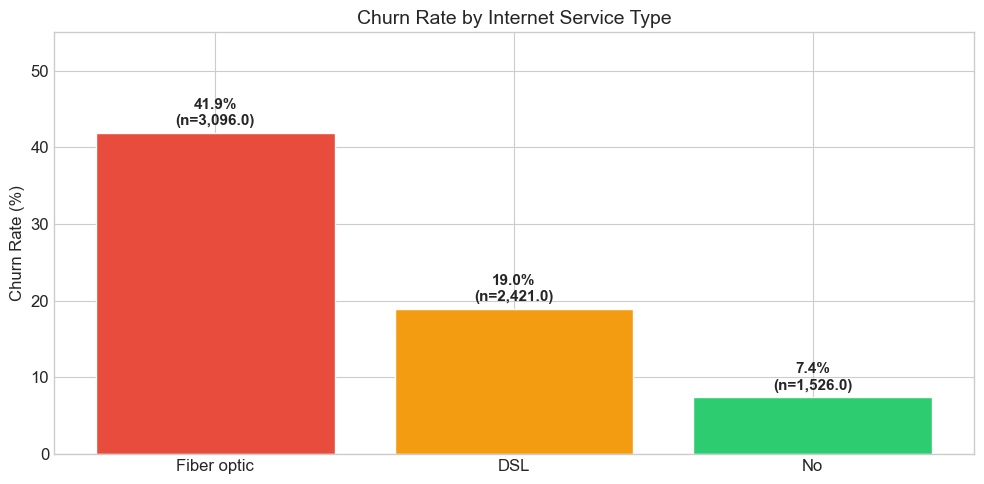


Churn rates by internet service:
  Fiber optic    : 41.9%  (3,096 customers)
  DSL            : 19.0%  (2,421 customers)
  No             : 7.4%  (1,526 customers)


In [14]:
# Churn Rate by Internet Service Type
# The SQL analysis above revealed that internet service-type has a major
# impact on customer churn. Will visualise it now.

fig, ax = plt.subplots(figsize=(10, 5))

internet_churn = df.groupby('InternetService')['Churn_binary'].agg(['mean', 'count'])
internet_churn.columns = ['Churn_Rate', 'Count']
internet_churn['Churn_Rate'] = internet_churn['Churn_Rate'] * 100
internet_order = ['Fiber optic', 'DSL', 'No']
internet_churn = internet_churn.reindex(internet_order)

bars = ax.bar(internet_churn.index, internet_churn['Churn_Rate'], 
              color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white')
ax.set_title('Churn Rate by Internet Service Type')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 55)

for bar, (idx, row) in zip(bars, internet_churn.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{row["Churn_Rate"]:.1f}%\n(n={row["Count"]:,})', 
            ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('fig3_churn_by_internet.png', dpi=300, bbox_inches='tight')
plt.show()

# Let's examine the numbers
print("\nChurn rates by internet service:")
for idx, row in internet_churn.iterrows():
    print(f"  {idx:15s}: {row['Churn_Rate']:.1f}%  ({int(row['Count']):,} customers)")


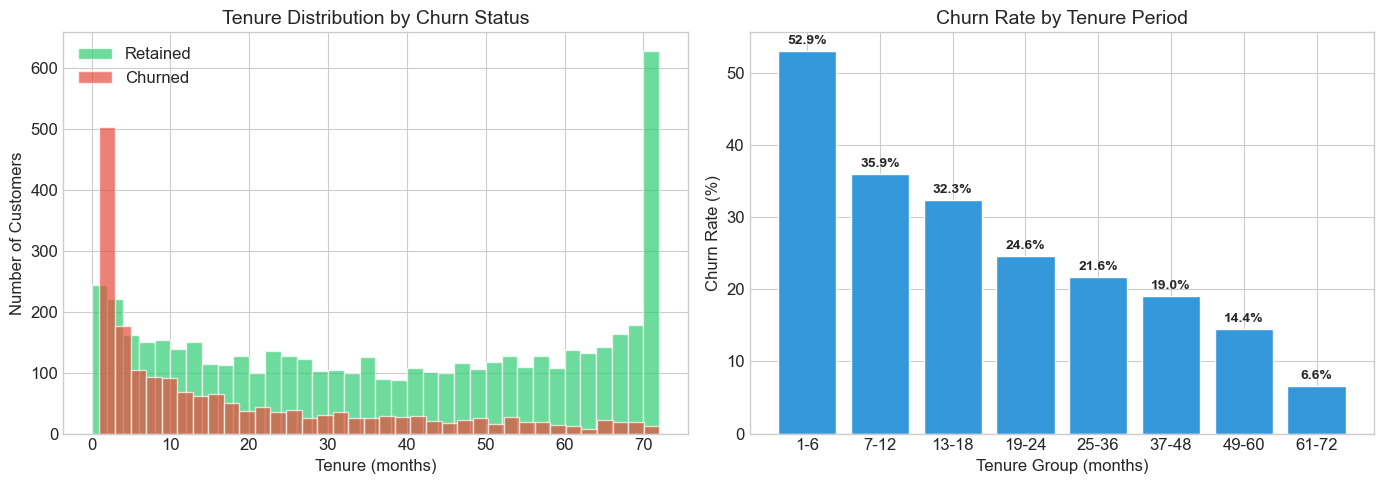


Churn rate by tenure period:
  Months 1-6  : 52.9%
  Months 7-12 : 35.9%
  Months 13-18: 32.3%
  Months 19-24: 24.6%
  Months 25-36: 21.6%
  Months 37-48: 19.0%
  Months 49-60: 14.4%
  Months 61-72: 6.6%

Average tenure — Churned: 18.0 months
Average tenure — Retained: 37.6 months


In [15]:
# Customer churn by Tenure — When Do Customers Leave?
# During industry research, I understood how tenure represents a 
# customers lifecycle: trial -- settling -- renewal cliff -- loyal.
# Let's see if the data supports this finding.


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Tenure distribution — churned vs retained
axes[0].hist(df[df['Churn']=='No']['tenure'], bins=36, alpha=0.7, 
             label='Retained', color='#2ecc71', edgecolor='white')
axes[0].hist(df[df['Churn']=='Yes']['tenure'], bins=36, alpha=0.7, 
             label='Churned', color='#e74c3c', edgecolor='white')
axes[0].set_title('Tenure Distribution by Churn Status')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

# Plot 2: Churn rate by tenure group
tenure_bins = [0, 6, 12, 18, 24, 36, 48, 60, 72]
tenure_labels = ['1-6', '7-12', '13-18', '19-24', '25-36', '37-48', '49-60', '61-72']
df['tenure_group'] = pd.cut(df['tenure'], bins=tenure_bins, 
                            labels=tenure_labels, include_lowest=True)

tenure_churn = df.groupby('tenure_group', observed=True)['Churn_binary'].mean() * 100

bars = axes[1].bar(tenure_churn.index, tenure_churn.values, 
                    color='#3498db', edgecolor='white')
axes[1].set_title('Churn Rate by Tenure Period')
axes[1].set_xlabel('Tenure Group (months)')
axes[1].set_ylabel('Churn Rate (%)')

for bar, val in zip(bars, tenure_churn.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('fig4_churn_by_tenure.png', dpi=300, bbox_inches='tight')
plt.show()

# Let's look at the numbers to understand the pattern
print("\nChurn rate by tenure period:")
for period, rate in tenure_churn.items():
    print(f"  Months {period:5s}: {rate:.1f}%")

# What's the average tenure of churners vs retained?
avg_tenure_churn = df[df['Churn']=='Yes']['tenure'].mean()
avg_tenure_stay = df[df['Churn']=='No']['tenure'].mean()
print(f"\nAverage tenure — Churned: {avg_tenure_churn:.1f} months")
print(f"Average tenure — Retained: {avg_tenure_stay:.1f} months")



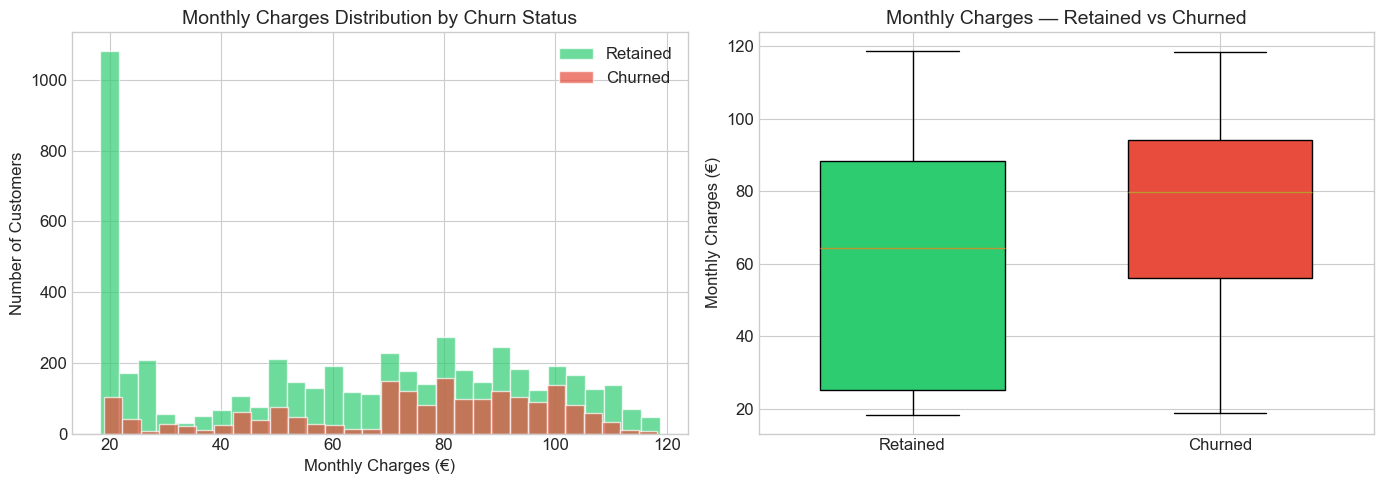

Monthly charges comparison:
  Retained customers: €61.27 avg
  Churned customers:  €74.44 avg
  Difference:         €13.18


In [16]:
# Monthly Charges comparison between, churnered and retained customers
# Do customers who leave pay more or less than those who stay?
# Let's compare this distribution of monthly charges.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Overlapping histograms
axes[0].hist(df[df['Churn']=='No']['MonthlyCharges'], bins=30, alpha=0.7, 
             label='Retained', color='#2ecc71', edgecolor='white')
axes[0].hist(df[df['Churn']=='Yes']['MonthlyCharges'], bins=30, alpha=0.7, 
             label='Churned', color='#e74c3c', edgecolor='white')
axes[0].set_title('Monthly Charges Distribution by Churn Status')
axes[0].set_xlabel('Monthly Charges (€)')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

# Plot 2: Box plot comparison
churn_data = [df[df['Churn']=='No']['MonthlyCharges'], 
              df[df['Churn']=='Yes']['MonthlyCharges']]
bp = axes[1].boxplot(churn_data, labels=['Retained', 'Churned'], 
                      patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
axes[1].set_title('Monthly Charges — Retained vs Churned')
axes[1].set_ylabel('Monthly Charges (€)')

plt.tight_layout()
plt.savefig('fig5_monthly_charges.png', dpi=300, bbox_inches='tight')
plt.show()

# comparison of averages
print("Monthly charges comparison:")
print(f"  Retained customers: €{df[df['Churn']=='No']['MonthlyCharges'].mean():.2f} avg")
print(f"  Churned customers:  €{df[df['Churn']=='Yes']['MonthlyCharges'].mean():.2f} avg")
print(f"  Difference:         €{df[df['Churn']=='Yes']['MonthlyCharges'].mean() - df[df['Churn']=='No']['MonthlyCharges'].mean():.2f}")

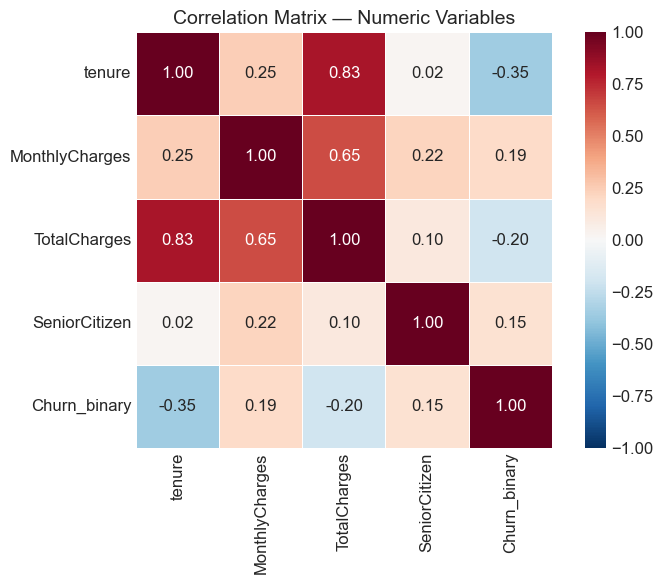

Correlations with Churn:
  tenure              : -0.352  (↓ less churn)
  TotalCharges        : -0.198  (↓ less churn)
  SeniorCitizen       : +0.151  (↑ more churn)
  MonthlyCharges      : +0.193  (↑ more churn)


In [17]:
# CELL 15: Correlation Heatmap
# Now we shall look at how the numeric variables relate to each other
# and to churn. This helps identify which features might be
# the most useful for our predictive models.

# Selecting numeric columns
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 
                'SeniorCitizen', 'Churn_binary']

correlation_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', square=True, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Correlation Matrix — Numeric Variables')

plt.tight_layout()
plt.savefig('fig6_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Correlations with Churn:")
churn_corr = correlation_matrix['Churn_binary'].drop('Churn_binary').sort_values()
for feat, corr in churn_corr.items():
    direction = "↑ more churn" if corr > 0 else "↓ less churn"
    print(f"  {feat:20s}: {corr:+.3f}  ({direction})")

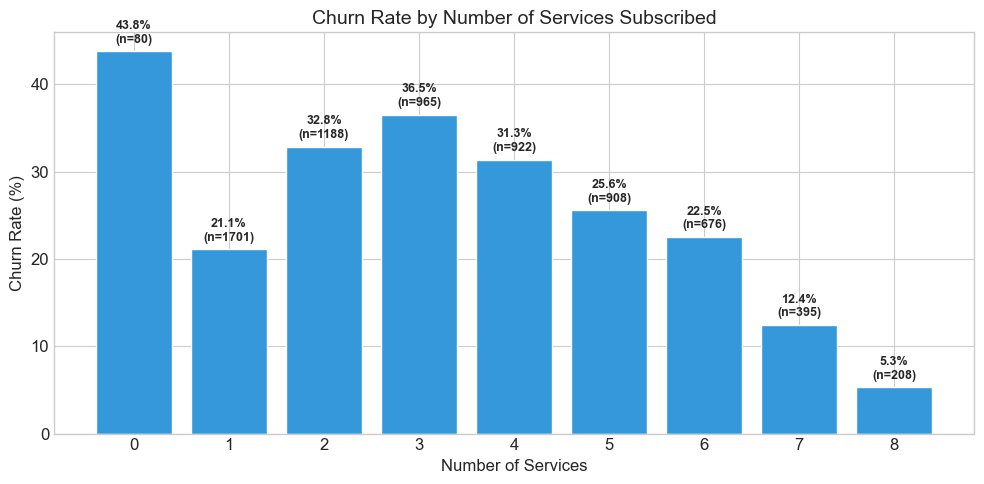

Churn rate by number of services:
  0 services: 43.8%  (80 customers)
  1 services: 21.1%  (1701 customers)
  2 services: 32.8%  (1188 customers)
  3 services: 36.5%  (965 customers)
  4 services: 31.3%  (922 customers)
  5 services: 25.6%  (908 customers)
  6 services: 22.5%  (676 customers)
  7 services: 12.4%  (395 customers)
  8 services: 5.3%  (208 customers)


In [18]:
# Service Adoption vs Churn — The Bundle Effect(telecoms have these services wherein the bundle a lot of services 
# provided by them such as calling, internet, 
# softwares etc together to craete packages)

# The question we are exploring here: does having more services 
# make a customer less likely to leave? If subscribing to 
# multiple services creates switching friction, we might 
# expect churn to decrease as the number of services increases.

# Counting the number of additional services per customer
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 
                'OnlineBackup', 'DeviceProtection', 'TechSupport', 
                'StreamingTV', 'StreamingMovies']

# Counting 'Yes' values across service columns
df['num_services'] = df[service_cols].apply(
    lambda row: sum(1 for val in row if val == 'Yes'), axis=1)

fig, ax = plt.subplots(figsize=(10, 5))

service_churn = df.groupby('num_services')['Churn_binary'].agg(['mean', 'count'])
service_churn.columns = ['Churn_Rate', 'Count']
service_churn['Churn_Rate'] = service_churn['Churn_Rate'] * 100

# Only plot groups with meaningful sample sizes
service_churn = service_churn[service_churn['Count'] >= 30]

bars = ax.bar(service_churn.index, service_churn['Churn_Rate'], 
              color='#3498db', edgecolor='white')
ax.set_title('Churn Rate by Number of Services Subscribed')
ax.set_xlabel('Number of Services')
ax.set_ylabel('Churn Rate (%)')
ax.set_xticks(service_churn.index)

for bar, (idx, row) in zip(bars, service_churn.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{row["Churn_Rate"]:.1f}%\n(n={int(row["Count"])})', 
            ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig7_bundle_effect.png', dpi=300, bbox_inches='tight')
plt.show()

print("Churn rate by number of services:")
for idx, row in service_churn.iterrows():
    print(f"  {idx} services: {row['Churn_Rate']:.1f}%  ({int(row['Count'])} customers)")

Telecom industry-driven feature engineering 

In [19]:
# Our data explorations and visualisations above have revealed ample of patterns:
# - Contract type, internet service, and tenure are strong churn indicators
# - Higher monthly charges are associated with higher churn
# - Having more services appears to reduce churn (from 4+ services)
# - Payment method matters (electronic check = high churn)
#
# So rather than feeding raw columns into our models, let's create 
# new features that capture the business logic behind these patterns.
print("CURRENT COLUMNS IN DATASET")
print("="*50)
print(f"Total columns: {df.shape[1]}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nWe will now engineer new features based on our Exploratory and visual data analysis findings.")

CURRENT COLUMNS IN DATASET
Total columns: 24

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_binary', 'tenure_group', 'num_services']

We will now engineer new features based on our Exploratory and visual data analysis findings.


In [20]:
# Tenure Risk Phase
# Our tenure analysis showed a clear lifecycle pattern:
# - Months 1-6:   52.9% churn (highest risk)
# - Months 7-12:  35.9% 
# - Months 13-24: ~28%
# - Months 25+:   steadily declining
#
# Instead of treating tenure as a raw number, let's categorise 
# customers into lifecycle phases. This captures the non-linear 
# relationship between tenure and churn that a linear model 
# might miss.

def assign_tenure_phase(tenure):
    if tenure <= 6:
        return 'Trial'
    elif tenure <= 18:
        return 'Settling'
    elif tenure <= 24:
        return 'Renewal_Cliff'
    else:
        return 'Loyal'

df['tenure_phase'] = df['tenure'].apply(assign_tenure_phase)

# Let's verify this captures the churn pattern
print("Churn rate by tenure phase:")
print("-"*50)
phase_churn = df.groupby('tenure_phase')['Churn_binary'].agg(['mean', 'count'])
phase_churn.columns = ['Churn_Rate', 'Count']
phase_order = ['Trial', 'Settling', 'Renewal_Cliff', 'Loyal']
phase_churn = phase_churn.reindex(phase_order)

for phase, row in phase_churn.iterrows():
    print(f"  {phase:16s}: {row['Churn_Rate']*100:.1f}%  ({int(row['Count'])} customers)")
      

Churn rate by tenure phase:
--------------------------------------------------
  Trial           : 52.9%  (1481 customers)
  Settling        : 34.3%  (1253 customers)
  Renewal_Cliff   : 24.6%  (476 customers)
  Loyal           : 14.0%  (3833 customers)


In [21]:
# Feature 1 — Service Bundle Depth
# Our bundle effect analysis showed that customers with more 
# services tend to churn less (especially 4+ services).
# Let's formalise this as a 'bundle depth' score (variable/feature we are creating).

service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                'TechSupport', 'StreamingTV', 'StreamingMovies']

# Count how many add-on services each customer has
# (excluding base phone/internet which nearly everyone has)
df['service_bundle_depth'] = df[service_cols].apply(
    lambda row: sum(1 for val in row if val == 'Yes'), axis=1)

print("Service bundle depth distribution:")
print("-"*50)
bundle_dist = df.groupby('service_bundle_depth')['Churn_binary'].agg(['mean', 'count'])
bundle_dist.columns = ['Churn_Rate', 'Count']

for depth, row in bundle_dist.iterrows():
    print(f"  {depth} add-on services: {row['Churn_Rate']*100:.1f}% churn  ({int(row['Count'])} customers)")

print(f"\nAverage bundle depth — Churned:  {df[df['Churn']=='Yes']['service_bundle_depth'].mean():.2f}")
print(f"Average bundle depth — Retained: {df[df['Churn']=='No']['service_bundle_depth'].mean():.2f}")

Service bundle depth distribution:
--------------------------------------------------
  0 add-on services: 21.4% churn  (2219 customers)
  1 add-on services: 45.8% churn  (966 customers)
  2 add-on services: 35.8% churn  (1033 customers)
  3 add-on services: 27.4% churn  (1118 customers)
  4 add-on services: 22.3% churn  (852 customers)
  5 add-on services: 12.4% churn  (571 customers)
  6 add-on services: 5.3% churn  (284 customers)

Average bundle depth — Churned:  1.77
Average bundle depth — Retained: 2.14


In [22]:
# Feature 2 — Price Sensitivity Score


# We observed that churners pay €13 more on average. But raw 
# monthly charges don't tell the full story — €80/month might 
# be reasonable for a customer with 6 services but expensive 
# for someone with just internet.
#
# Price sensitivity score will tell us, how much a customer pays relative to 
# what's typical for their contract type and bundle size.
# A higher score implies they're paying more than peers with 
# similar setups — making them more likely to feel overcharged.

# Calculating average monthly charge for each contract + bundle combination
avg_charges = df.groupby(['Contract', 'service_bundle_depth'])['MonthlyCharges'].transform('mean')

# Price sensitivity: ratio of actual charge to peer average
# > 1.0 means paying more than similar customers
df['price_sensitivity'] = df['MonthlyCharges'] / avg_charges

print("Price sensitivity distribution:")
print("-"*50)
print(df['price_sensitivity'].describe().round(3))

print(f"\nAverage price sensitivity — Churned:  {df[df['Churn']=='Yes']['price_sensitivity'].mean():.3f}")
print(f"Average price sensitivity — Retained: {df[df['Churn']=='No']['price_sensitivity'].mean():.3f}")

# Do high price-sensitivity customers churn more?
df['price_sensitivity_group'] = pd.cut(df['price_sensitivity'], 
                                        bins=[0, 0.9, 1.0, 1.1, 2.0],
                                        labels=['Low (<0.9)', 'Average (0.9-1.0)', 
                                                'Slightly High (1.0-1.1)', 'High (>1.1)'])

print(f"\nChurn rate by price sensitivity:")
ps_churn = df.groupby('price_sensitivity_group', observed=True)['Churn_binary'].agg(['mean','count'])
for group, row in ps_churn.iterrows():
    print(f"  {group:25s}: {row['mean']*100:.1f}% churn  ({int(row['count'])} customers)")

Price sensitivity distribution:
--------------------------------------------------
count    7043.000
mean        1.000
std         0.314
min         0.430
25%         0.818
50%         1.052
75%         1.185
max         3.437
Name: price_sensitivity, dtype: float64

Average price sensitivity — Churned:  1.111
Average price sensitivity — Retained: 0.960

Churn rate by price sensitivity:
  Low (<0.9)               : 17.3% churn  (2625 customers)
  Average (0.9-1.0)        : 3.9% churn  (788 customers)
  Slightly High (1.0-1.1)  : 31.6% churn  (529 customers)
  High (>1.1)              : 39.4% churn  (3086 customers)


In [23]:
# Feature 3 — Payment Friction Indicator
# Our Data exploration and visualisation showed electronic check payers churn at 45.3% vs 
# a 15-19% for automatic payment methods. This suggests that 
# customers who manually pay each month have less commitment or maybe a psychological effect.
#
# Hence creating a feature to captures this: does the customer 
# have automatic payment set up?

df['auto_payment'] = df['PaymentMethod'].apply(
    lambda x: 1 if 'automatic' in x.lower() else 0)

print("Auto-payment vs manual payment:")
print("-"*50)
payment_churn = df.groupby('auto_payment')['Churn_binary'].agg(['mean', 'count'])
payment_churn.index = ['Manual payment', 'Auto payment']
for method, row in payment_churn.iterrows():
    print(f"  {method:20s}: {row['mean']*100:.1f}% churn  ({int(row['count'])} customers)")

Auto-payment vs manual payment:
--------------------------------------------------
  Manual payment      : 34.7% churn  (3977 customers)
  Auto payment        : 16.0% churn  (3066 customers)


In [24]:
# Feature 4 — Charge to Tenure Ratio
# A customer who is paying €90/month who has been with the company for 
# 3 months is very different from one paying €90/month for 5 years.
# The first is a high-paying newcomer (high risk), the second is 
# a loyal premium customer (low risk).
#
# This ratio captures that distinction.

# Avoiding division by zero for tenure=0 customers
df['charge_tenure_ratio'] = df['MonthlyCharges'] / (df['tenure'] + 1)

print("Charge-to-tenure ratio:")
print("-"*50)
print(df['charge_tenure_ratio'].describe().round(3))

print(f"\nAverage ratio — Churned:  {df[df['Churn']=='Yes']['charge_tenure_ratio'].mean():.3f}")
print(f"Average ratio — Retained: {df[df['Churn']=='No']['charge_tenure_ratio'].mean():.3f}")

Charge-to-tenure ratio:
--------------------------------------------------
count    7043.000
mean        5.771
std         8.722
min         0.264
25%         1.250
50%         2.076
75%         5.946
max        80.850
Name: charge_tenure_ratio, dtype: float64

Average ratio — Churned:  11.746
Average ratio — Retained: 3.612


In [25]:
# Feature Engineering Summary
# Reviewing all the new features created and confirming that
# the dataset is ready for modelling.

new_features = ['tenure_phase', 'service_bundle_depth', 'price_sensitivity', 
                'auto_payment', 'charge_tenure_ratio']

print("ENGINEERED FEATURES SUMMARY")
print("="*60)
for feat in new_features:
    churned_avg = df[df['Churn']=='Yes'][feat].mean() if df[feat].dtype != 'object' else 'categorical'
    retained_avg = df[df['Churn']=='No'][feat].mean() if df[feat].dtype != 'object' else 'categorical'
    print(f"\n{feat}:")
    if churned_avg != 'categorical':
        print(f"  Churned avg:  {churned_avg:.3f}")
        print(f"  Retained avg: {retained_avg:.3f}")
    else:
        print(f"  {df[feat].value_counts().to_string()}")

print(f"\n{'='*60}")
print(f"Dataset shape before feature engineering: 7043 × 21")
print(f"Dataset shape after feature engineering:  {df.shape[0]} × {df.shape[1]}")
print(f"New features added: {len(new_features)}")

ENGINEERED FEATURES SUMMARY

tenure_phase:
  tenure_phase
Loyal            3833
Trial            1481
Settling         1253
Renewal_Cliff     476

service_bundle_depth:
  Churned avg:  1.768
  Retained avg: 2.135

price_sensitivity:
  Churned avg:  1.111
  Retained avg: 0.960

auto_payment:
  Churned avg:  0.262
  Retained avg: 0.498

charge_tenure_ratio:
  Churned avg:  11.746
  Retained avg: 3.612

Dataset shape before feature engineering: 7043 × 21
Dataset shape after feature engineering:  7043 × 30
New features added: 5


In [26]:
# Data Prep for Modelling
# Things to do before building any models, 
# 1. Select the features to use
# 2. Encoding categorical variables as numbers
# 3. Splitting data into training and testing sets
#
# Will start by selecting our features. Will drop some columns that 
# aren't useful for prediction (customerID, raw Churn text) and 
# temporary columns I created during Data exploration.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Dropping columns that aren't useful 
drop_cols = ['customerID', 'Churn', 'Churn_binary', 'tenure_group', 
             'num_services', 'price_sensitivity_group']

# Target variable
target = df['Churn_binary']

# Everything except what I am dropping
features = df.drop(columns=drop_cols)

print("Features selected for modelling:")
print("-"*50)
print(f"Total features: {features.shape[1]}")
print(f"\nNumeric features:")
numeric_feats = features.select_dtypes(include=['int64','float64']).columns.tolist()
for f in numeric_feats:
    print(f"  {f}")

print(f"\nCategorical features (need encoding):")
cat_feats = features.select_dtypes(include=['object']).columns.tolist()
for f in cat_feats:
    print(f"  {f}  —  {features[f].nunique()} unique values")

Features selected for modelling:
--------------------------------------------------
Total features: 24

Numeric features:
  SeniorCitizen
  tenure
  MonthlyCharges
  TotalCharges
  service_bundle_depth
  price_sensitivity
  auto_payment
  charge_tenure_ratio

Categorical features (need encoding):
  gender  —  2 unique values
  Partner  —  2 unique values
  Dependents  —  2 unique values
  PhoneService  —  2 unique values
  MultipleLines  —  3 unique values
  InternetService  —  3 unique values
  OnlineSecurity  —  3 unique values
  OnlineBackup  —  3 unique values
  DeviceProtection  —  3 unique values
  TechSupport  —  3 unique values
  StreamingTV  —  3 unique values
  StreamingMovies  —  3 unique values
  Contract  —  3 unique values
  PaperlessBilling  —  2 unique values
  PaymentMethod  —  4 unique values
  tenure_phase  —  4 unique values


In [27]:
# Encoding Categorical Variables
# Machine learning models require numeric input. Hence 
# convert categorical (text) variables into numbers.
# 
# Will be using one-hot encoding — this creates a separate binary 
# column for each category. For example, Contract becomes:
# Contract_Month-to-month, Contract_One year, Contract_Two year

features_encoded = pd.get_dummies(features, drop_first=True)

print(f"Shape before encoding: {features.shape}")
print(f"Shape after encoding:  {features_encoded.shape}")
print(f"\nNew column count: {features_encoded.shape[1]} features")
print(f"\nAll columns:")
for i, col in enumerate(features_encoded.columns, 1):
    print(f"  {i:2d}. {col}")

Shape before encoding: (7043, 24)
Shape after encoding:  (7043, 37)

New column count: 37 features

All columns:
   1. SeniorCitizen
   2. tenure
   3. MonthlyCharges
   4. TotalCharges
   5. service_bundle_depth
   6. price_sensitivity
   7. auto_payment
   8. charge_tenure_ratio
   9. gender_Male
  10. Partner_Yes
  11. Dependents_Yes
  12. PhoneService_Yes
  13. MultipleLines_No phone service
  14. MultipleLines_Yes
  15. InternetService_Fiber optic
  16. InternetService_No
  17. OnlineSecurity_No internet service
  18. OnlineSecurity_Yes
  19. OnlineBackup_No internet service
  20. OnlineBackup_Yes
  21. DeviceProtection_No internet service
  22. DeviceProtection_Yes
  23. TechSupport_No internet service
  24. TechSupport_Yes
  25. StreamingTV_No internet service
  26. StreamingTV_Yes
  27. StreamingMovies_No internet service
  28. StreamingMovies_Yes
  29. Contract_One year
  30. Contract_Two year
  31. PaperlessBilling_Yes
  32. PaymentMethod_Credit card (automatic)
  33. Payment

In [28]:
# Data split for, Train-Test 
# Splitting the data into training (80%) and rest to testing (20%).
# 
# Important factor I am keeping: I am implying stratified splitting to make sure that the same 
# churn ratio (26.5%) is preserved in both the split-sets. Choosing to ignore this, 
# might accidentally get 30% churn in training and 20% in 
# testing, which would skew the results.

X_train, X_test, y_train, y_test = train_test_split(
    features_encoded, target, test_size=0.2, 
    random_state=42, stratify=target
)

print("TRAIN-TEST SPLIT")
print("="*50)
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"Testing set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(df)*100:.0f}%)")

print(f"\nChurn ratio preserved?")
print(f"  Original:  {target.mean()*100:.1f}%")
print(f"  Training:  {y_train.mean()*100:.1f}%")
print(f"  Testing:   {y_test.mean()*100:.1f}%")

print(f"\n✅ Stratified split confirmed — churn ratio maintained")

TRAIN-TEST SPLIT
Training set: 5634 samples (80%)
Testing set:  1409 samples (20%)

Churn ratio preserved?
  Original:  26.5%
  Training:  26.5%
  Testing:   26.5%

✅ Stratified split confirmed — churn ratio maintained


In [29]:
# Handling Class Imbalance with SMOTE
# the dataset is imbalanced — only 26.5% of customers churned.
# This means a model could achieve 73.5% accuracy by simply 
# predicting "no churn" for everyone — which will be useless.
#
# SMOTE (Synthetic Minority Oversampling Technique) creates 
# synthetic examples of the minority class (churned customers) 
# to balance the training data.
#
# CRITICAL: Will only apply SMOTE to the training set, not 
# to the test set. Since The test set must remain untouched to give 
# an honest evaluation of model performance.


from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("SMOTE OVERSAMPLING")
print("="*50)
print(f"\nBefore SMOTE (training set):")
print(f"  Not churned: {(y_train==0).sum()}")
print(f"  Churned:     {(y_train==1).sum()}")
print(f"  Ratio:       {y_train.mean()*100:.1f}% churned")

print(f"\nAfter SMOTE (training set):")
print(f"  Not churned: {(y_train_balanced==0).sum()}")
print(f"  Churned:     {(y_train_balanced==1).sum()}")
print(f"  Ratio:       {y_train_balanced.mean()*100:.1f}% churned")

print(f"\nTest set (untouched):")
print(f"  Not churned: {(y_test==0).sum()}")
print(f"  Churned:     {(y_test==1).sum()}")

SMOTE OVERSAMPLING

Before SMOTE (training set):
  Not churned: 4139
  Churned:     1495
  Ratio:       26.5% churned

After SMOTE (training set):
  Not churned: 4139
  Churned:     4139
  Ratio:       50.0% churned

Test set (untouched):
  Not churned: 1035
  Churned:     374


In [30]:
# Stupid-Simple Baseline

# Before building any complex models, I am  testing a question:
# Can a simple business rule predict churn reasonably well?
#
# Rule to be followed: Flag any customer who is on a month-to-month contract 
# AND has been with the company for less than 12 months.
#
# If this simple rule performs well, it raises an important 
# question about whether we even need machine learning.
# If ML significantly outperforms it, that justifies the 
# added complexity.

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Applying the rule formed to the original test data (the one before encoding)

test_indices = X_test.index
baseline_predictions = (
    (df.loc[test_indices, 'Contract'] == 'Month-to-month') & 
    (df.loc[test_indices, 'tenure'] < 12)
).astype(int)

print("BASELINE MODEL: Simple Business Rule")
print("Rule: Month-to-month contract + Tenure < 12 months = Churn")
print("="*55)
print(f"\nCustomers flagged as 'will churn': {baseline_predictions.sum()} out of {len(baseline_predictions)}")
print(f"Actual churners in test set:      {y_test.sum()} out of {len(y_test)}")

print(f"\nPerformance metrics:")
print(f"  Accuracy:  {accuracy_score(y_test, baseline_predictions)*100:.1f}%")
print(f"  Precision: {precision_score(y_test, baseline_predictions)*100:.1f}%")
print(f"  Recall:    {recall_score(y_test, baseline_predictions)*100:.1f}%")
print(f"  F1 Score:  {f1_score(y_test, baseline_predictions)*100:.1f}%")

print(f"\nConfusion Matrix:")
cm = confusion_matrix(y_test, baseline_predictions)
print(f"  True Negatives  (correctly predicted stay):  {cm[0][0]}")
print(f"  False Positives (predicted churn, but stayed): {cm[0][1]}")
print(f"  False Negatives (predicted stay, but churned): {cm[1][0]}")
print(f"  True Positives  (correctly predicted churn):  {cm[1][1]}")

BASELINE MODEL: Simple Business Rule
Rule: Month-to-month contract + Tenure < 12 months = Churn

Customers flagged as 'will churn': 384 out of 1409
Actual churners in test set:      374 out of 1409

Performance metrics:
  Accuracy:  75.3%
  Precision: 53.4%
  Recall:    54.8%
  F1 Score:  54.1%

Confusion Matrix:
  True Negatives  (correctly predicted stay):  856
  False Positives (predicted churn, but stayed): 179
  False Negatives (predicted stay, but churned): 169
  True Positives  (correctly predicted churn):  205


In [31]:
# Model 1 — Logistic Regression


# Logistic regression is a traditional statistical model for 
# binary classification. It's interpretable and serves as our 
# ML baseline — how much does a standard statistical approach 
# improve over the simple business rule?

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

# Training the model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train_balanced)

# Prediction based on test set
lr_predictions = lr_model.predict(X_test_scaled)

print("MODEL 1: Logistic Regression")
print("="*55)
print(f"\nPerformance metrics:")
print(f"  Accuracy:  {accuracy_score(y_test, lr_predictions)*100:.1f}%")
print(f"  Precision: {precision_score(y_test, lr_predictions)*100:.1f}%")
print(f"  Recall:    {recall_score(y_test, lr_predictions)*100:.1f}%")
print(f"  F1 Score:  {f1_score(y_test, lr_predictions)*100:.1f}%")

print(f"\nConfusion Matrix:")
cm_lr = confusion_matrix(y_test, lr_predictions)
print(f"  True Negatives:  {cm_lr[0][0]}")
print(f"  False Positives: {cm_lr[0][1]}")
print(f"  False Negatives: {cm_lr[1][0]}")
print(f"  True Positives:  {cm_lr[1][1]}")

MODEL 1: Logistic Regression

Performance metrics:
  Accuracy:  79.3%
  Precision: 61.2%
  Recall:    59.9%
  F1 Score:  60.5%

Confusion Matrix:
  True Negatives:  893
  False Positives: 142
  False Negatives: 150
  True Positives:  224


In [32]:
# Model 2 — Random Forest


# Random Forest is an ensemble method — it builds many decision 
# trees and combines their predictions. It can capture non-linear 
# patterns that a logistic regression might miss.


from sklearn.ensemble import RandomForestClassifier

# Random Forest doesn't require feature scaling
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train_balanced, y_train_balanced)

rf_predictions = rf_model.predict(X_test)

print("MODEL 2: Random Forest")
print("="*55)
print(f"\nPerformance metrics:")
print(f"  Accuracy:  {accuracy_score(y_test, rf_predictions)*100:.1f}%")
print(f"  Precision: {precision_score(y_test, rf_predictions)*100:.1f}%")
print(f"  Recall:    {recall_score(y_test, rf_predictions)*100:.1f}%")
print(f"  F1 Score:  {f1_score(y_test, rf_predictions)*100:.1f}%")

print(f"\nConfusion Matrix:")
cm_rf = confusion_matrix(y_test, rf_predictions)
print(f"  True Negatives:  {cm_rf[0][0]}")
print(f"  False Positives: {cm_rf[0][1]}")
print(f"  False Negatives: {cm_rf[1][0]}")
print(f"  True Positives:  {cm_rf[1][1]}")

MODEL 2: Random Forest

Performance metrics:
  Accuracy:  77.1%
  Precision: 56.8%
  Recall:    57.8%
  F1 Score:  57.3%

Confusion Matrix:
  True Negatives:  871
  False Positives: 164
  False Negatives: 158
  True Positives:  216


In [33]:
# Model 3 — XGBoost


# XGBoost (Extreme Gradient Boosting) is a gradient boosting 
# algorithm that builds trees sequentially — each new tree 
# tries to correct the mistakes of the previous ones.
# It's widely regarded as one of the best algorithms for 
# structured/tabular data. Let's see how this one compares to the pother methods.

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200, 
    max_depth=6,
    learning_rate=0.1,
    random_state=42, 
    use_label_encoder=False, 
    eval_metric='logloss'
)
xgb_model.fit(X_train_balanced, y_train_balanced)

xgb_predictions = xgb_model.predict(X_test)

print("MODEL 3: XGBoost")
print("="*55)
print(f"\nPerformance metrics:")
print(f"  Accuracy:  {accuracy_score(y_test, xgb_predictions)*100:.1f}%")
print(f"  Precision: {precision_score(y_test, xgb_predictions)*100:.1f}%")
print(f"  Recall:    {recall_score(y_test, xgb_predictions)*100:.1f}%")
print(f"  F1 Score:  {f1_score(y_test, xgb_predictions)*100:.1f}%")

print(f"\nConfusion Matrix:")
cm_xgb = confusion_matrix(y_test, xgb_predictions)
print(f"  True Negatives:  {cm_xgb[0][0]}")
print(f"  False Positives: {cm_xgb[0][1]}")
print(f"  False Negatives: {cm_xgb[1][0]}")
print(f"  True Positives:  {cm_xgb[1][1]}")

MODEL 3: XGBoost

Performance metrics:
  Accuracy:  77.0%
  Precision: 56.5%
  Recall:    58.0%
  F1 Score:  57.3%

Confusion Matrix:
  True Negatives:  868
  False Positives: 167
  False Negatives: 157
  True Positives:  217


In [34]:
# Model Comparison Table
# Comparing all four approaches side by side to see 
# how much value each model adds over the simple rule.

from sklearn.metrics import roc_auc_score

results = {
    'Business Rule': {
        'predictions': baseline_predictions,
        'model': None
    },
    'Logistic Regression': {
        'predictions': lr_predictions,
        'model': lr_model,
        'X_test': X_test_scaled
    },
    'Random Forest': {
        'predictions': rf_predictions,
        'model': rf_model,
        'X_test': X_test
    },
    'XGBoost': {
        'predictions': xgb_predictions,
        'model': xgb_model,
        'X_test': X_test
    }
}

print("MODEL COMPARISON")
print("="*75)
print(f"{'Model':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'ROC-AUC':>10}")
print("-"*75)

for name, data in results.items():
    acc = accuracy_score(y_test, data['predictions']) * 100
    prec = precision_score(y_test, data['predictions']) * 100
    rec = recall_score(y_test, data['predictions']) * 100
    f1 = f1_score(y_test, data['predictions']) * 100
    
    if data['model'] is not None:
        proba = data['model'].predict_proba(data['X_test'])[:, 1]
        auc = roc_auc_score(y_test, proba) * 100
        print(f"{name:<22} {acc:>9.1f}% {prec:>9.1f}% {rec:>9.1f}% {f1:>9.1f}% {auc:>9.1f}%")
    else:
        print(f"{name:<22} {acc:>9.1f}% {prec:>9.1f}% {rec:>9.1f}% {f1:>9.1f}%       N/A")

print("-"*75)
print("\nNote: ROC-AUC requires probability scores, which the business rule cannot provide.")

MODEL COMPARISON
Model                    Accuracy  Precision     Recall         F1    ROC-AUC
---------------------------------------------------------------------------
Business Rule               75.3%      53.4%      54.8%      54.1%       N/A
Logistic Regression         79.3%      61.2%      59.9%      60.5%      83.7%
Random Forest               77.1%      56.8%      57.8%      57.3%      81.9%
XGBoost                     77.0%      56.5%      58.0%      57.3%      81.5%
---------------------------------------------------------------------------

Note: ROC-AUC requires probability scores, which the business rule cannot provide.


In [35]:
# Pushing it further with Hyperparameter Tuning in XGBoost


# Logistic Regression is currently outperforming Random Forest 
# and XGBoost. Before drawing conclusions, I am trying tuning 
# XGBoost's hyperparameters — as it's highly possible that the default 
# settings aren't optimal for this dataset.
#
# Using GridSearchCV to systematically test different 
# combinations and find the best configuration.

from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0]
}

print("Starting hyperparameter tuning...")
print(f"Testing {len(param_grid['max_depth']) * len(param_grid['learning_rate']) * len(param_grid['n_estimators']) * len(param_grid['subsample'])} combinations")
print("This may take a few minutes...\n")

xgb_tuned = XGBClassifier(
    random_state=42, 
    use_label_encoder=False, 
    eval_metric='logloss'
)

grid_search = GridSearchCV(
    xgb_tuned, param_grid, 
    cv=5, scoring='f1', 
    n_jobs=-1, verbose=0
)
grid_search.fit(X_train_balanced, y_train_balanced)

print(f"Best parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest cross-validation F1: {grid_search.best_score_*100:.1f}%")

# Evaluation of the tuned model on test set
xgb_tuned_model = grid_search.best_estimator_
xgb_tuned_predictions = xgb_tuned_model.predict(X_test)

print(f"\nTUNED XGBoost — Test Set Performance:")
print(f"  Accuracy:  {accuracy_score(y_test, xgb_tuned_predictions)*100:.1f}%")
print(f"  Precision: {precision_score(y_test, xgb_tuned_predictions)*100:.1f}%")
print(f"  Recall:    {recall_score(y_test, xgb_tuned_predictions)*100:.1f}%")
print(f"  F1 Score:  {f1_score(y_test, xgb_tuned_predictions)*100:.1f}%")

xgb_tuned_proba = xgb_tuned_model.predict_proba(X_test)[:, 1]
print(f"  ROC-AUC:   {roc_auc_score(y_test, xgb_tuned_proba)*100:.1f}%")

Starting hyperparameter tuning...
Testing 96 combinations
This may take a few minutes...

Best parameters found:
  learning_rate: 0.05
  max_depth: 4
  n_estimators: 100
  subsample: 1.0

Best cross-validation F1: 83.0%

TUNED XGBoost — Test Set Performance:
  Accuracy:  76.9%
  Precision: 55.4%
  Recall:    66.8%
  F1 Score:  60.6%
  ROC-AUC:   83.3%


In [36]:
# Updated Model Comparison with Tuned XGBoost
# The tuned XGBoost improved significantly on recall. 
# So we shall update our comparison table with the final results.

print("FINAL MODEL COMPARISON")
print("="*80)
print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'ROC-AUC':>10}")
print("-"*80)

# Recalculating all metrics including tuned XGBoost
final_models = {
    'Business Rule': (baseline_predictions, None),
    'Logistic Regression': (lr_predictions, lr_model.predict_proba(X_test_scaled)[:, 1]),
    'Random Forest': (rf_predictions, rf_model.predict_proba(X_test)[:, 1]),
    'XGBoost (default)': (xgb_predictions, xgb_model.predict_proba(X_test)[:, 1]),
    'XGBoost (tuned)': (xgb_tuned_predictions, xgb_tuned_proba)
}

for name, (preds, proba) in final_models.items():
    acc = accuracy_score(y_test, preds) * 100
    prec = precision_score(y_test, preds) * 100
    rec = recall_score(y_test, preds) * 100
    f1 = f1_score(y_test, preds) * 100
    auc_str = f"{roc_auc_score(y_test, proba)*100:.1f}%" if proba is not None else "N/A"
    print(f"{name:<25} {acc:>9.1f}% {prec:>9.1f}% {rec:>9.1f}% {f1:>9.1f}% {auc_str:>10}")

print("-"*80)

FINAL MODEL COMPARISON
Model                       Accuracy  Precision     Recall         F1    ROC-AUC
--------------------------------------------------------------------------------
Business Rule                  75.3%      53.4%      54.8%      54.1%        N/A
Logistic Regression            79.3%      61.2%      59.9%      60.5%      83.7%
Random Forest                  77.1%      56.8%      57.8%      57.3%      81.9%
XGBoost (default)              77.0%      56.5%      58.0%      57.3%      81.5%
XGBoost (tuned)                76.9%      55.4%      66.8%      60.6%      83.3%
--------------------------------------------------------------------------------


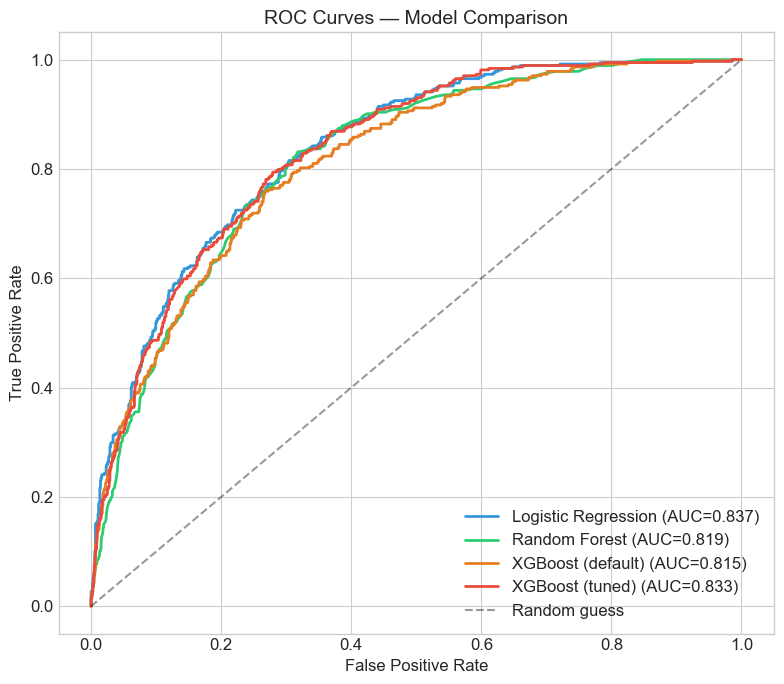

ROC-AUC Scores:
  Logistic Regression      : 0.837
  Random Forest            : 0.819
  XGBoost (default)        : 0.815
  XGBoost (tuned)          : 0.833


In [37]:
# ROC Curve Comparison
# The ROC curve shows the trade-off between catching churners 


from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 7))

# Plot each model's ROC curve
models_for_roc = {
    'Logistic Regression': lr_model.predict_proba(X_test_scaled)[:, 1],
    'Random Forest': rf_model.predict_proba(X_test)[:, 1],
    'XGBoost (default)': xgb_model.predict_proba(X_test)[:, 1],
    'XGBoost (tuned)': xgb_tuned_proba
}

colors = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']

for (name, proba), color in zip(models_for_roc.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

# Random guess line
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random guess')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('fig8_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Print the AUC scores for comparison
print("ROC-AUC Scores:")
for name, proba in models_for_roc.items():
    print(f"  {name:<25}: {roc_auc_score(y_test, proba):.3f}")

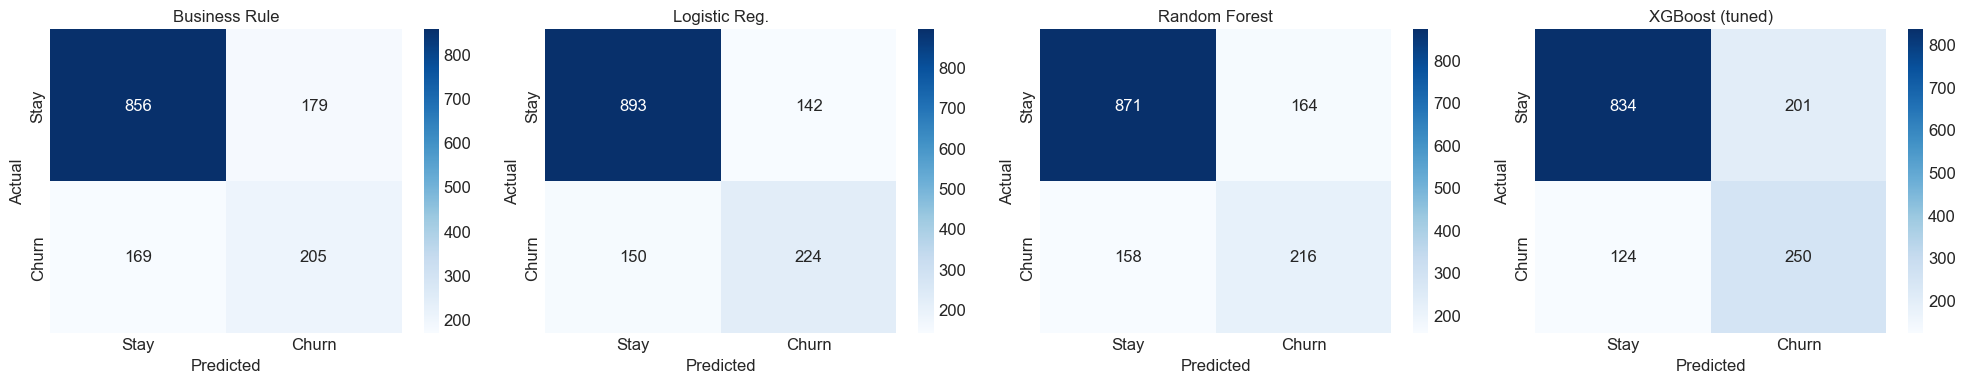

In [38]:
# Confusion Matrices — Visual Comparison
# Visualising the confusion matrices side by side 
# to see the pattern of errors each model makes.

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

models_cm = {
    'Business Rule': baseline_predictions,
    'Logistic Reg.': lr_predictions,
    'Random Forest': rf_predictions,
    'XGBoost (tuned)': xgb_tuned_predictions
}

for ax, (name, preds) in zip(axes, models_cm.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Stay', 'Churn'], 
                yticklabels=['Stay', 'Churn'])
    ax.set_title(name, fontsize=12)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('fig9_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

In [39]:
#  Modelling Phase — Key Observations
# Summarising what I've observed from the model comparison:

print("KEY OBSERVATIONS")
print("="*65)

print("""
1. BASELINE RULE PERFORMANCE
   The simple rule (month-to-month + tenure < 12) achieved 54.1% F1.
   It catches about half the churners — not bad for zero ML.
   This tells us that contract type and tenure alone explain a 
   large portion of churn behaviour.

2. ML IMPROVEMENT OVER BASELINE
   All three ML models outperformed the business rule:
   - Best F1: Tuned XGBoost (60.6%) and Logistic Regression (60.5%)
   - Best Recall: Tuned XGBoost (66.8%) — catches 2/3 of churners
   - Best Precision: Logistic Regression (61.2%)
   - Best AUC: Logistic Regression (0.837)
   
   ML improves F1 by ~6.5 percentage points over the simple rule.
   This is a meaningful but not dramatic improvement.

3. MODEL SELECTION
   For a churn prediction system, recall matters most — the cost 
   of missing a churner (lost revenue) far exceeds the cost of 
   a false alarm (unnecessary discount).
   
   The tuned XGBoost catches 250 churners vs 205 for the business 
   rule — that's 45 additional customers saved.
   
   We will proceed with the TUNED XGBoost as our primary model 
   for the explainability and business strategy phases.

4. HONEST ASSESSMENT
   The improvement from ML is real but modest. A significant 
   portion of churn is explainable by simple business factors. 
   The true value of the ML approach lies not in raw prediction 
   accuracy, but in the probability scores and feature-level 
   explanations (SHAP) that enable targeted interventions — 
   something a simple rule cannot provide.
""")

KEY OBSERVATIONS

1. BASELINE RULE PERFORMANCE
   The simple rule (month-to-month + tenure < 12) achieved 54.1% F1.
   It catches about half the churners — not bad for zero ML.
   This tells us that contract type and tenure alone explain a 
   large portion of churn behaviour.

2. ML IMPROVEMENT OVER BASELINE
   All three ML models outperformed the business rule:
   - Best F1: Tuned XGBoost (60.6%) and Logistic Regression (60.5%)
   - Best Recall: Tuned XGBoost (66.8%) — catches 2/3 of churners
   - Best Precision: Logistic Regression (61.2%)
   - Best AUC: Logistic Regression (0.837)

   ML improves F1 by ~6.5 percentage points over the simple rule.
   This is a meaningful but not dramatic improvement.

3. MODEL SELECTION
   For a churn prediction system, recall matters most — the cost 
   of missing a churner (lost revenue) far exceeds the cost of 
   a false alarm (unnecessary discount).

   The tuned XGBoost catches 250 churners vs 205 for the business 
   rule — that's 45 addition

In [40]:
# Setting up for SHAP analysis
# Tuned XGBoost model predicts churn with 66.8% recall. 
# But a prediction score alone doesn't tell a retention manager 
# WHY a customer is at risk. 
#
# SHAP (SHapley Additive exPlanations) answers this by showing 
# how much each feature contributes to each individual prediction.
# This is what makes the model actionable rather than just descriptive.

import shap

# Creating SHAP explainer for our tuned XGBoost model
explainer = shap.TreeExplainer(xgb_tuned_model)

# Calculating SHAP values for the test set
shap_values = explainer.shap_values(X_test)

print(f"SHAP values calculated for {X_test.shape[0]} customers")
print(f"Features analysed: {X_test.shape[1]}")
print(f"\nShape of SHAP values: {shap_values.shape}")
print(f"Each customer now has a SHAP value for every feature,")
print(f"showing how that feature pushed the prediction toward")
print(f"or away from churn.")

SHAP values calculated for 1409 customers
Features analysed: 37

Shape of SHAP values: (1409, 37)
Each customer now has a SHAP value for every feature,
showing how that feature pushed the prediction toward
or away from churn.


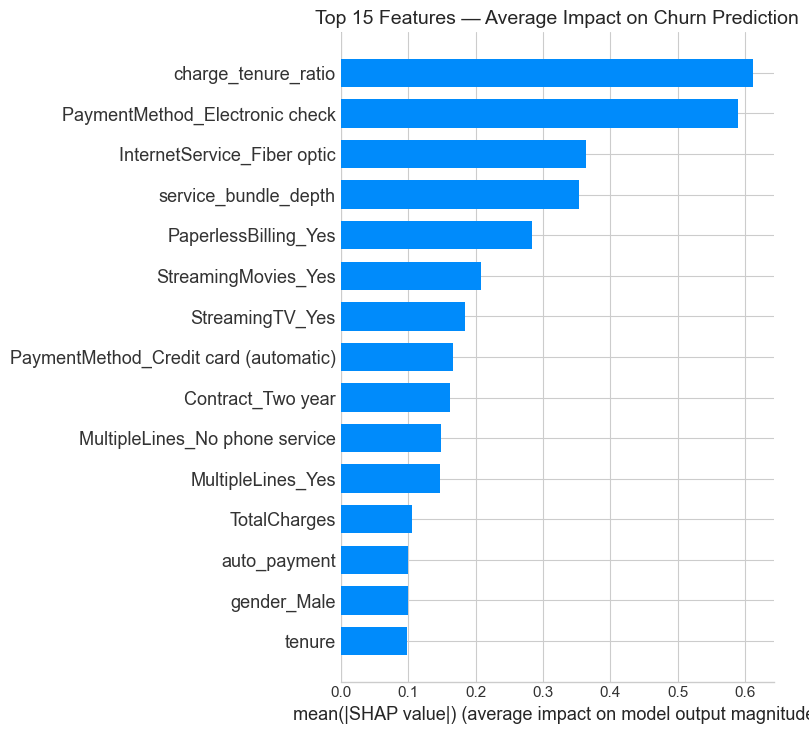

In [41]:
# Which features have the biggest overall impact on churn 
# predictions across all customers? The summary bar plot 
# shows the average absolute SHAP value for each feature.

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", 
                  show=False, max_display=15)
plt.title("Top 15 Features — Average Impact on Churn Prediction")
plt.tight_layout()
plt.savefig('fig10_shap_importance.png', dpi=300, bbox_inches='tight')
plt.show()

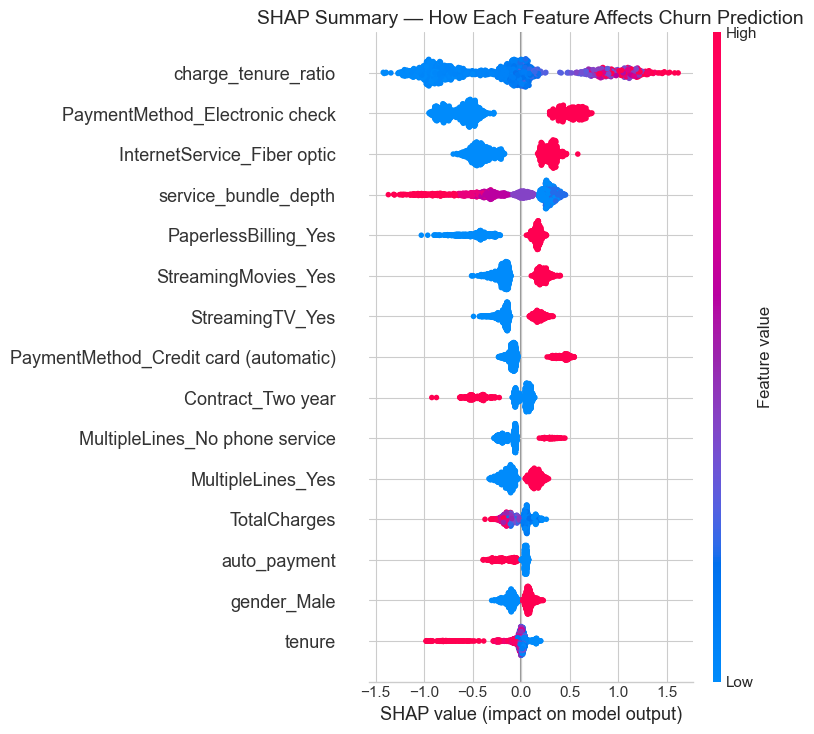

In [42]:
# SHAP — Detailed Summary Plot (Beeswarm)
# The bar plot shows which features matter the most, but not 
# the direction of their effects. The beeswarm plot shows both:
# - Each dot is one customer
# - Position on x-axis imply impact on prediction
# - Colour signifies feature value (red = high, blue = low)
#
# For example, if high tenure dots cluster on the left (negative 
# SHAP), that means longer tenure pushes prediction toward 
# "not churning" — which is what I am expecting.

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
plt.title("SHAP Summary — How Each Feature Affects Churn Prediction")
plt.tight_layout()
plt.savefig('fig11_shap_beeswarm.png', dpi=300, bbox_inches='tight')
plt.show()

In [43]:
# SHAP — Individual Customer Explanations
# Selecting specific customers from the test set and observing
# exactly why the model flagged them as high or low risk.
# This is what I believe a retention manager would see in practice.

# Gathering churn probabilities for all test customers
churn_probabilities = xgb_tuned_model.predict_proba(X_test)[:, 1]

# Finding a high-risk customer (one of the highest churn probabilities)
high_risk_idx = churn_probabilities.argsort()[-1]

# Now finding a low-risk customer (one of the lowest churn probabilities)  
low_risk_idx = churn_probabilities.argsort()[0]

print("HIGH-RISK CUSTOMER EXAMPLE")
print("="*55)
print(f"Predicted churn probability: {churn_probabilities[high_risk_idx]*100:.1f}%")
print(f"Actual outcome: {'Churned' if y_test.iloc[high_risk_idx] == 1 else 'Stayed'}")
print(f"\nTop features driving this prediction:")

# Getting SHAP values for this customer and sort by impact
high_risk_shap = pd.Series(shap_values[high_risk_idx], 
                            index=X_test.columns).sort_values(ascending=False)
for feat, val in high_risk_shap.head(5).items():
    direction = "↑ pushes toward churn" if val > 0 else "↓ pushes away from churn"
    print(f"  {feat:35s}: {val:+.3f}  ({direction})")

print(f"\n\nLOW-RISK CUSTOMER EXAMPLE")
print("="*55)
print(f"Predicted churn probability: {churn_probabilities[low_risk_idx]*100:.1f}%")
print(f"Actual outcome: {'Churned' if y_test.iloc[low_risk_idx] == 1 else 'Stayed'}")
print(f"\nTop features driving this prediction:")

low_risk_shap = pd.Series(shap_values[low_risk_idx], 
                           index=X_test.columns).sort_values(ascending=True)
for feat, val in low_risk_shap.head(5).items():
    direction = "↑ pushes toward churn" if val > 0 else "↓ pushes away from churn"
    print(f"  {feat:35s}: {val:+.3f}  ({direction})")

HIGH-RISK CUSTOMER EXAMPLE
Predicted churn probability: 94.3%
Actual outcome: Churned

Top features driving this prediction:
  charge_tenure_ratio                : +1.255  (↑ pushes toward churn)
  service_bundle_depth               : +0.410  (↑ pushes toward churn)
  PaymentMethod_Electronic check     : +0.384  (↑ pushes toward churn)
  StreamingMovies_Yes                : +0.261  (↑ pushes toward churn)
  InternetService_Fiber optic        : +0.237  (↑ pushes toward churn)


LOW-RISK CUSTOMER EXAMPLE
Predicted churn probability: 1.2%
Actual outcome: Stayed

Top features driving this prediction:
  charge_tenure_ratio                : -0.987  (↓ pushes away from churn)
  tenure                             : -0.801  (↓ pushes away from churn)
  Contract_Two year                  : -0.527  (↓ pushes away from churn)
  PaymentMethod_Electronic check     : -0.473  (↓ pushes away from churn)
  PaperlessBilling_Yes               : -0.414  (↓ pushes away from churn)


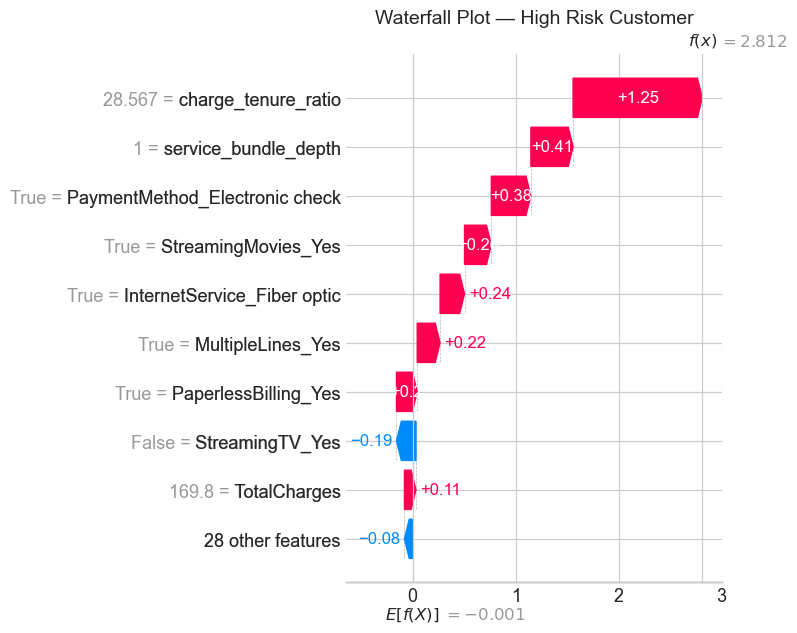

In [44]:
# SHAP Waterfall — High Risk Customer
# The waterfall plot shows the step-by-step breakdown of 
# how each feature moves the prediction from the base value 
# (average prediction) to this specific customer's score.

fig, ax = plt.subplots(figsize=(10, 6))
shap.waterfall_plot(shap.Explanation(
    values=shap_values[high_risk_idx], 
    base_values=explainer.expected_value,
    data=X_test.iloc[high_risk_idx],
    feature_names=X_test.columns.tolist()
), show=False, max_display=10)
plt.title("Waterfall Plot — High Risk Customer")
plt.tight_layout()
plt.savefig('fig12_shap_waterfall_high.png', dpi=300, bbox_inches='tight')
plt.show()

In [45]:
# SHAP -- Action Mapping


# SHAP tells us WHY customers churn. Now the question is:
# what should the business do about each of these drivers ?
#
# Let's map each top churn driver to a specific, actionable 
# CRM intervention that a retention team could implement.

shap_action_map = pd.DataFrame({
    'Churn Driver': [
        'High charge_tenure_ratio',
        'Electronic check payment',
        'Fiber optic internet',
        'Low service_bundle_depth',
        'Paperless billing',
        'No streaming services',
        'Month-to-month contract'
    ],
    'What It Means': [
        'New customer paying high prices — feels overcharged',
        'Manual payment = low commitment, no auto-renewal friction',
        'Tech-savvy, price-sensitive, exposed to competitor offers',
        'Few services = low switching cost, easy to leave',
        'No paper bills = less brand touchpoint, easier to forget',
        'Fewer reasons to stay — not using the full platform',
        'Zero contractual barrier to leaving'
    ],
    'Recommended CRM Action': [
        'Offer loyalty discount after month 3. Match competitor pricing.',
        'Incentivise switch to auto-pay (e.g., €5/month discount)',
        'Proactive service quality check. Dedicated support line.',
        'Cross-sell bundle: "Add security + backup for €10/month"',
        'Send personalised usage summaries by email to build engagement',
        'Offer free streaming trial for 3 months as retention hook',
        'Offer discounted annual contract at month 10 (before renewal cliff)'
    ]
})

print("SHAP -- ACTION MAPPING")
print("="*80)
for _, row in shap_action_map.iterrows():
    print(f"\n  Driver:  {row['Churn Driver']}")
    print(f"  Meaning: {row['What It Means']}")
    print(f"  Action:  {row['Recommended CRM Action']}")

print(f"\n{'='*80}")
print("Each SHAP insight now has a specific, implementable retention action.")
print("This transforms the model from a prediction tool into a decision support system.")

SHAP -- ACTION MAPPING

  Driver:  High charge_tenure_ratio
  Meaning: New customer paying high prices — feels overcharged
  Action:  Offer loyalty discount after month 3. Match competitor pricing.

  Driver:  Electronic check payment
  Meaning: Manual payment = low commitment, no auto-renewal friction
  Action:  Incentivise switch to auto-pay (e.g., €5/month discount)

  Driver:  Fiber optic internet
  Meaning: Tech-savvy, price-sensitive, exposed to competitor offers
  Action:  Proactive service quality check. Dedicated support line.

  Driver:  Low service_bundle_depth
  Meaning: Few services = low switching cost, easy to leave
  Action:  Cross-sell bundle: "Add security + backup for €10/month"

  Driver:  Paperless billing
  Meaning: No paper bills = less brand touchpoint, easier to forget
  Action:  Send personalised usage summaries by email to build engagement

  Driver:  No streaming services
  Meaning: Fewer reasons to stay — not using the full platform
  Action:  Offer free st

In [46]:
# Customer Lifetime Value (CLV) calculation
# A churn probability alone doesn't tell us which customers 
# are WORTH saving. A high-risk customer paying €20/month is 
# very different from one paying €100/month.
#
# CLV estimates the future revenue a customer shall generate.
# Simple formula for that: Monthly Charges × Expected Remaining Tenure
#
# For expected remaining tenure, ia m using the average tenure of 
# retained customers in the same contract type as a proxy.

# Calculating average tenure by contract type for retained customers
avg_tenure_by_contract = df[df['Churn']=='No'].groupby('Contract')['tenure'].mean()
max_tenure = 72  # maximum observed tenure in the dataset

print("Average tenure of retained customers by contract type:")
for contract, avg in avg_tenure_by_contract.items():
    print(f"  {contract:20s}: {avg:.1f} months")

# Estimating remaining tenure: expected total - current tenure
# (minimum 0 — can't have negative remaining time)
df['expected_total_tenure'] = df['Contract'].map(avg_tenure_by_contract)
df['remaining_tenure'] = (df['expected_total_tenure'] - df['tenure']).clip(lower=1)

# CLV = Monthly Charges × Remaining Tenure
df['CLV'] = df['MonthlyCharges'] * df['remaining_tenure']

print(f"\nCUSTOMER LIFETIME VALUE DISTRIBUTION")
print("="*55)
print(df['CLV'].describe().round(2))

print(f"\nCLV comparison:")
print(f"  Churned customers avg CLV:  €{df[df['Churn']=='Yes']['CLV'].mean():,.2f}")
print(f"  Retained customers avg CLV: €{df[df['Churn']=='No']['CLV'].mean():,.2f}")

Average tenure of retained customers by contract type:
  Month-to-month      : 21.0 months
  One year            : 41.7 months
  Two year            : 56.6 months

CUSTOMER LIFETIME VALUE DISTRIBUTION
count    7043.00
mean      466.15
std       546.85
min        18.40
25%        83.68
50%       134.15
75%       773.21
max      4576.35
Name: CLV, dtype: float64

CLV comparison:
  Churned customers avg CLV:  €721.64
  Retained customers avg CLV: €373.86


In [47]:
#  Value × Risk Matrix — Customer Segmentation
# Now i am combining churn probability with CLV to create the 
# 2×2 segmentation matrix. This shall answer a critical question:
# "Which customers are acyaully worth saving?"
#
# We need churn probabilities for all customers, not just 
# the test set. Let's hop onto the prediction aspect.

# Encoding the full dataset the same way I did at the time of modelling
full_features = features_encoded.copy()

# Getting churn probabilities for all customers
all_churn_proba = xgb_tuned_model.predict_proba(full_features)[:, 1]
df['churn_probability'] = all_churn_proba

# Defining segments using median splits
clv_median = df['CLV'].median()
risk_threshold = 0.5  # 50% churn probability as high-risk cutoff

def assign_segment(row):
    high_value = row['CLV'] >= clv_median
    high_risk = row['churn_probability'] >= risk_threshold
    
    if high_value and high_risk:
        return 'Priority Save'
    elif high_value and not high_risk:
        return 'Nurture'
    elif not high_value and high_risk:
        return 'Low-Cost Nudge'
    else:
        return 'Monitor'

df['segment'] = df.apply(assign_segment, axis=1)

print("VALUE × RISK SEGMENTATION")
print("="*65)

segment_summary = df.groupby('segment').agg(
    count=('customerID', 'count'),
    avg_churn_prob=('churn_probability', 'mean'),
    avg_clv=('CLV', 'mean'),
    avg_monthly=('MonthlyCharges', 'mean'),
    actual_churn_rate=('Churn_binary', 'mean')
).round(2)

segment_order = ['Priority Save', 'Nurture', 'Low-Cost Nudge', 'Monitor']
segment_summary = segment_summary.reindex(segment_order)

for seg, row in segment_summary.iterrows():
    print(f"\n  {seg.upper()}")
    print(f"    Customers:          {int(row['count'])}")
    print(f"    Avg churn prob:     {row['avg_churn_prob']*100:.1f}%")
    print(f"    Avg CLV:            €{row['avg_clv']:,.2f}")
    print(f"    Avg monthly charge: €{row['avg_monthly']:.2f}")
    print(f"    Actual churn rate:  {row['actual_churn_rate']*100:.1f}%")

VALUE × RISK SEGMENTATION

  PRIORITY SAVE
    Customers:          1684
    Avg churn prob:     74.0%
    Avg CLV:            €1,036.60
    Avg monthly charge: €68.04
    Actual churn rate:  62.0%

  NURTURE
    Customers:          1838
    Avg churn prob:     19.0%
    Avg CLV:            €691.91
    Avg monthly charge: €46.87
    Actual churn rate:  12.0%

  LOW-COST NUDGE
    Customers:          508
    Avg churn prob:     67.0%
    Avg CLV:            €94.47
    Avg monthly charge: €93.78
    Actual churn rate:  52.0%

  MONITOR
    Customers:          3013
    Avg churn prob:     16.0%
    Avg CLV:            €72.26
    Avg monthly charge: €68.95
    Actual churn rate:  11.0%


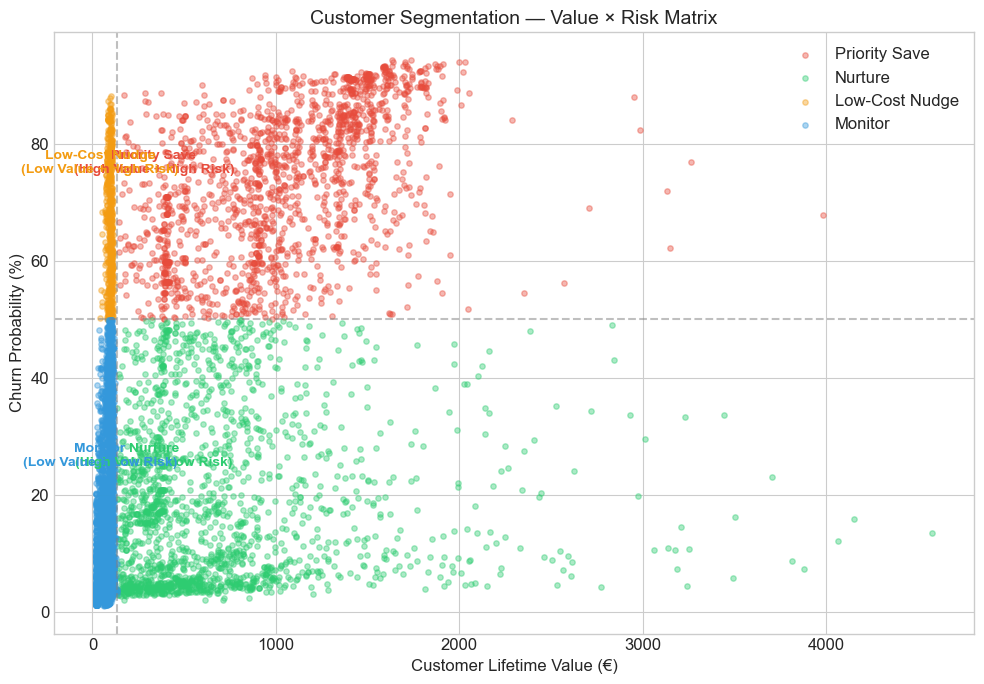

In [48]:
# Visualising the above Matrix
# Plotting the 2×2 matrix to see how customers are distributed 
# across the four segments.

fig, ax = plt.subplots(figsize=(10, 7))

colors_map = {
    'Priority Save': '#e74c3c',
    'Nurture': '#2ecc71', 
    'Low-Cost Nudge': '#f39c12',
    'Monitor': '#3498db'
}

for segment, color in colors_map.items():
    mask = df['segment'] == segment
    ax.scatter(df.loc[mask, 'CLV'], 
              df.loc[mask, 'churn_probability'] * 100,
              c=color, label=segment, alpha=0.4, s=15)

# Quadrant lines
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=clv_median, color='gray', linestyle='--', alpha=0.5)

# Labelling to quadrants
ax.text(clv_median * 2.5, 75, 'Priority Save\n(High Value + High Risk)', 
        ha='center', fontweight='bold', color='#e74c3c', fontsize=10)
ax.text(clv_median * 2.5, 25, 'Nurture\n(High Value + Low Risk)', 
        ha='center', fontweight='bold', color='#2ecc71', fontsize=10)
ax.text(clv_median * 0.3, 75, 'Low-Cost Nudge\n(Low Value + High Risk)', 
        ha='center', fontweight='bold', color='#f39c12', fontsize=10)
ax.text(clv_median * 0.3, 25, 'Monitor\n(Low Value + Low Risk)', 
        ha='center', fontweight='bold', color='#3498db', fontsize=10)

ax.set_xlabel('Customer Lifetime Value (€)')
ax.set_ylabel('Churn Probability (%)')
ax.set_title('Customer Segmentation — Value × Risk Matrix')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('fig13_value_risk_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [49]:
#  Model Stress Test — Where Does It Fail?
# A responsible analyst doesn't just report accuracy — they 
# actively look for where the model breaks down. Which customers 
# does it get wrong, and are there patterns in those errors?

# Getting predictions and probabilities for test set
test_predictions = xgb_tuned_model.predict(X_test)
test_probabilities = xgb_tuned_model.predict_proba(X_test)[:, 1]

# Creating a dataframe of test results
test_results = df.loc[X_test.index].copy()
test_results['predicted_churn'] = test_predictions
test_results['churn_probability'] = test_probabilities
test_results['correct'] = (test_results['Churn_binary'] == test_results['predicted_churn'])

# False Negatives: Customers who churned but the model missed them 
false_negatives = test_results[(test_results['Churn_binary']==1) & 
                                (test_results['predicted_churn']==0)]

print("FALSE NEGATIVES — Churners the model MISSED")
print("="*60)
print(f"Count: {len(false_negatives)} out of {y_test.sum()} actual churners")
print(f"\nProfile of missed churners:")
print(f"  Avg tenure:          {false_negatives['tenure'].mean():.1f} months")
print(f"  Avg monthly charge:  €{false_negatives['MonthlyCharges'].mean():.2f}")
print(f"  Avg churn prob:      {false_negatives['churn_probability'].mean()*100:.1f}%")

print(f"\n  Contract breakdown:")
for contract, count in false_negatives['Contract'].value_counts().items():
    pct = count / len(false_negatives) * 100
    print(f"    {contract:20s}: {count} ({pct:.1f}%)")

print(f"\n  Internet service:")
for svc, count in false_negatives['InternetService'].value_counts().items():
    pct = count / len(false_negatives) * 100
    print(f"    {svc:20s}: {count} ({pct:.1f}%)")

# False Positives: Model flagged them but they stayed 
false_positives = test_results[(test_results['Churn_binary']==0) & 
                                (test_results['predicted_churn']==1)]

print(f"\n\nFALSE POSITIVES — Flagged as churners but actually STAYED")
print("="*60)
print(f"Count: {len(false_positives)} out of {(y_test==0).sum()} non-churners")
print(f"\nProfile of falsely flagged customers:")
print(f"  Avg tenure:          {false_positives['tenure'].mean():.1f} months")
print(f"  Avg monthly charge:  €{false_positives['MonthlyCharges'].mean():.2f}")
print(f"  Avg churn prob:      {false_positives['churn_probability'].mean()*100:.1f}%")

print(f"\n  Contract breakdown:")
for contract, count in false_positives['Contract'].value_counts().items():
    pct = count / len(false_positives) * 100
    print(f"    {contract:20s}: {count} ({pct:.1f}%)")

FALSE NEGATIVES — Churners the model MISSED
Count: 124 out of 374 actual churners

Profile of missed churners:
  Avg tenure:          30.2 months
  Avg monthly charge:  €71.56
  Avg churn prob:      29.3%

  Contract breakdown:
    Month-to-month      : 87 (70.2%)
    One year            : 28 (22.6%)
    Two year            : 9 (7.3%)

  Internet service:
    Fiber optic         : 65 (52.4%)
    DSL                 : 46 (37.1%)
    No                  : 13 (10.5%)


FALSE POSITIVES — Flagged as churners but actually STAYED
Count: 201 out of 1035 non-churners

Profile of falsely flagged customers:
  Avg tenure:          16.5 months
  Avg monthly charge:  €73.11
  Avg churn prob:      67.8%

  Contract breakdown:
    Month-to-month      : 176 (87.6%)
    One year            : 22 (10.9%)
    Two year            : 3 (1.5%)


In [50]:
# Is the model we created overconfident? Let's check if customers with 
# very high predicted probabilities actually churn at the 
# rate the model expects.

# Group by probability ranges and compare predicted vs actual
prob_bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
prob_labels = ['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']

test_results['prob_group'] = pd.cut(test_results['churn_probability'], 
                                     bins=prob_bins, labels=prob_labels)

print("MODEL CALIBRATION — Predicted vs Actual Churn Rate")
print("="*65)
print(f"{'Predicted Range':<18} {'Count':>8} {'Predicted Avg':>15} {'Actual Rate':>15}")
print("-"*65)

calibration = test_results.groupby('prob_group', observed=True).agg(
    count=('Churn_binary', 'count'),
    predicted_avg=('churn_probability', 'mean'),
    actual_rate=('Churn_binary', 'mean')
)

for group, row in calibration.iterrows():
    predicted_pct = row['predicted_avg'] * 100
    actual_pct = row['actual_rate'] * 100
    gap = actual_pct - predicted_pct
    flag = " ⚠️" if abs(gap) > 15 else ""
    print(f"{group:<18} {int(row['count']):>8} {predicted_pct:>14.1f}% {actual_pct:>14.1f}%{flag}")

print(f"\n⚠️ = gap between predicted and actual exceeds 15 percentage points")

MODEL CALIBRATION — Predicted vs Actual Churn Rate
Predicted Range       Count   Predicted Avg     Actual Rate
-----------------------------------------------------------------
0-20%                   623            8.2%            6.1%
20-40%                  231           29.3%           22.1%
40-60%                  205           50.1%           33.7% ⚠️
60-80%                  210           70.5%           53.8% ⚠️
80-100%                 140           86.2%           73.6%

⚠️ = gap between predicted and actual exceeds 15 percentage points


In [51]:
# Financial Analysis - The Cost of model errors
# In the real world every model error has a financial consequence within the business. But the cost 
# of different errors is not equal:
#
# False Negative (missed churner): We lose a customer we could 
# have saved. Cost = their remaining CLV.
#
# False Positive (unnecessary intervention): We spend money on  
# a customer who was never going to leave. Cost = the retention 
# offer we gave them.
#
# Let's quantify this financial cost using our data.

# Average CLV of churners (what we lose per missed customer)
avg_clv_churner = df[df['Churn']=='Yes']['CLV'].mean()

# Estimated cost of a retention intervention
# (industry standard: ~€40-50 for a loyalty discount/offer)
retention_cost = 40

print("COST OF MODEL ERRORS")
print("="*60)
print(f"\nCost of a False Negative (missed churner):")
print(f"  Average lost CLV: €{avg_clv_churner:,.2f}")
print(f"  This is a customer who left that we could have saved.")

print(f"\nCost of a False Positive (unnecessary intervention):")
print(f"  Retention offer cost: €{retention_cost}")
print(f"  This is a discount given to someone who was staying anyway.")

ratio = avg_clv_churner / retention_cost
print(f"\nCost ratio: A missed churner costs {ratio:.0f}x more than a false alarm.")
print(f"This is why we optimise for RECALL — catching more churners")
print(f"is worth the cost of some unnecessary discounts.")

# Apply to our actual test set results
fn_count = len(false_negatives)
fp_count = len(false_positives)
tp_count = len(test_results[(test_results['Churn_binary']==1) & 
                             (test_results['predicted_churn']==1)])

fn_cost = fn_count * avg_clv_churner
fp_cost = fp_count * retention_cost
revenue_saved = tp_count * avg_clv_churner

print(f"\n\nFINANCIAL IMPACT ON TEST SET ({len(test_results)} customers)")
print("="*60)
print(f"  Churners correctly caught:    {tp_count}")
print(f"  Revenue saved:                €{revenue_saved:,.2f}")
print(f"  False alarms:                 {fp_count}")
print(f"  Cost of false alarms:         €{fp_cost:,.2f}")
print(f"  Churners missed:              {fn_count}")
print(f"  Revenue lost (missed):        €{fn_cost:,.2f}")
print(f"\n  Net value of model:           €{revenue_saved - fp_cost:,.2f}")

COST OF MODEL ERRORS

Cost of a False Negative (missed churner):
  Average lost CLV: €721.64
  This is a customer who left that we could have saved.

Cost of a False Positive (unnecessary intervention):
  Retention offer cost: €40
  This is a discount given to someone who was staying anyway.

Cost ratio: A missed churner costs 18x more than a false alarm.
This is why we optimise for RECALL — catching more churners
is worth the cost of some unnecessary discounts.


FINANCIAL IMPACT ON TEST SET (1409 customers)
  Churners correctly caught:    250
  Revenue saved:                €180,408.88
  False alarms:                 201
  Cost of false alarms:         €8,040.00
  Churners missed:              124
  Revenue lost (missed):        €89,482.81

  Net value of model:           €172,368.88


In [52]:
# Retention Budget Simulation
# Scenario I have chosen: The company has €50,000 per quarter for retention.
# How should they allocate it?
#
# Strategy A (Blanket): Give every flagged customer a €40 offer
# Strategy B (Targeted): Focus budget on Priority Save segment 
#            only, with higher-value interventions
#
# Simulating both on our full dataset.

budget = 50000

print("RETENTION BUDGET SIMULATION — €50,000/quarter")
print("="*65)

# --- Strategy A: Blanket approach ---
# Giving €40 retention offer to every customer with >50% churn probability
high_risk_all = df[df['churn_probability'] >= 0.5]
blanket_customers_reached = min(len(high_risk_all), int(budget / retention_cost))
blanket_expected_saves = blanket_customers_reached * high_risk_all['Churn_binary'].mean()
blanket_revenue_saved = blanket_expected_saves * high_risk_all['CLV'].mean()
blanket_cost = blanket_customers_reached * retention_cost

print(f"\nSTRATEGY A: Blanket — €{retention_cost} offer to all high-risk customers")
print(f"  Customers reached:     {blanket_customers_reached}")
print(f"  Budget spent:          €{blanket_cost:,.0f}")
print(f"  Expected saves:        {blanket_expected_saves:.0f} customers")
print(f"  Expected revenue saved:€{blanket_revenue_saved:,.0f}")
print(f"  ROI:                   {(blanket_revenue_saved/blanket_cost):.1f}x")

# --- Strategy B: Targeted — Priority Save only ---
priority_save = df[df['segment'] == 'Priority Save']
targeted_intervention_cost = 80  # higher value offer for priority customers
targeted_customers_reached = min(len(priority_save), int(budget / targeted_intervention_cost))
targeted_expected_saves = targeted_customers_reached * priority_save['Churn_binary'].mean()
targeted_revenue_saved = targeted_expected_saves * priority_save['CLV'].mean()
targeted_cost = targeted_customers_reached * targeted_intervention_cost

print(f"\nSTRATEGY B: Targeted — €{targeted_intervention_cost} premium offer to Priority Save only")
print(f"  Customers reached:     {targeted_customers_reached}")
print(f"  Budget spent:          €{targeted_cost:,.0f}")
print(f"  Expected saves:        {targeted_expected_saves:.0f} customers")
print(f"  Expected revenue saved:€{targeted_revenue_saved:,.0f}")
print(f"  ROI:                   {(targeted_revenue_saved/targeted_cost):.1f}x")

# --- Comparison of the two ---
print(f"\n{'='*65}")
print(f"COMPARISON")
print(f"  Strategy A ROI: {(blanket_revenue_saved/blanket_cost):.1f}x")
print(f"  Strategy B ROI: {(targeted_revenue_saved/targeted_cost):.1f}x")
print(f"\n  Revenue difference: €{targeted_revenue_saved - blanket_revenue_saved:,.0f}")

RETENTION BUDGET SIMULATION — €50,000/quarter

STRATEGY A: Blanket — €40 offer to all high-risk customers
  Customers reached:     1250
  Budget spent:          €50,000
  Expected saves:        746 customers
  Expected revenue saved:€610,333
  ROI:                   12.2x

STRATEGY B: Targeted — €80 premium offer to Priority Save only
  Customers reached:     625
  Budget spent:          €50,000
  Expected saves:        388 customers
  Expected revenue saved:€402,035
  ROI:                   8.0x

COMPARISON
  Strategy A ROI: 12.2x
  Strategy B ROI: 8.0x

  Revenue difference: €-208,298


In [53]:
# Ethics & Fairness Analysis
# An important question arises: does the defined model treat all demographic 
# groups fairly? Or does it disproportionately flag certain 
# groups for intervention — or worse, neglect them?
#
# Let's check two flagged concerns:
# 1. Does the model flag senior citizens at a higher rate?
# 2. Does CLV-based prioritisation disadvantage lower-income customers?

print("ETHICS & FAIRNESS ANALYSIS")
print("="*60)

# --- Check 1: Senior citizen bias ---
print("\n1. SENIOR CITIZEN ANALYSIS")
print("-"*60)

senior_stats = df.groupby('SeniorCitizen').agg(
    count=('customerID', 'count'),
    avg_churn_prob=('churn_probability', 'mean'),
    actual_churn=('Churn_binary', 'mean'),
    avg_clv=('CLV', 'mean'),
    pct_priority_save=('segment', lambda x: (x=='Priority Save').mean())
).round(3)

senior_stats.index = ['Non-Senior', 'Senior']

for group, row in senior_stats.iterrows():
    print(f"\n  {group} (n={int(row['count'])})")
    print(f"    Avg predicted churn probability: {row['avg_churn_prob']*100:.1f}%")
    print(f"    Actual churn rate:               {row['actual_churn']*100:.1f}%")
    print(f"    Avg CLV:                         €{row['avg_clv']:,.2f}")
    print(f"    Classified as Priority Save:     {row['pct_priority_save']*100:.1f}%")

# --- Check 2: Income-based triage ---
print(f"\n\n2. INCOME-BASED TRIAGE CHECK")
print("-"*60)
print("Does our Value × Risk matrix neglect low-spending customers?")

charge_quartiles = pd.qcut(df['MonthlyCharges'], q=4, 
                            labels=['Low', 'Medium-Low', 'Medium-High', 'High'])
df['charge_quartile'] = charge_quartiles

quartile_stats = df.groupby('charge_quartile', observed=True).agg(
    count=('customerID', 'count'),
    actual_churn=('Churn_binary', 'mean'),
    avg_churn_prob=('churn_probability', 'mean'),
    pct_priority=('segment', lambda x: (x=='Priority Save').mean()),
    pct_monitor=('segment', lambda x: (x=='Monitor').mean())
).round(3)

for group, row in quartile_stats.iterrows():
    print(f"\n  {group} spenders (n={int(row['count'])})")
    print(f"    Actual churn rate:         {row['actual_churn']*100:.1f}%")
    print(f"    Avg predicted risk:        {row['avg_churn_prob']*100:.1f}%")
    print(f"    In Priority Save:          {row['pct_priority']*100:.1f}%")
    print(f"    In Monitor (no action):    {row['pct_monitor']*100:.1f}%")

ETHICS & FAIRNESS ANALYSIS

1. SENIOR CITIZEN ANALYSIS
------------------------------------------------------------

  Non-Senior (n=5901)
    Avg predicted churn probability: 31.9%
    Actual churn rate:               23.6%
    Avg CLV:                         €470.58
    Classified as Priority Save:     22.6%

  Senior (n=1142)
    Avg predicted churn probability: 46.6%
    Actual churn rate:               41.7%
    Avg CLV:                         €443.23
    Classified as Priority Save:     30.8%


2. INCOME-BASED TRIAGE CHECK
------------------------------------------------------------
Does our Value × Risk matrix neglect low-spending customers?

  Low spenders (n=1762)
    Actual churn rate:         11.2%
    Avg predicted risk:        18.0%
    In Priority Save:          13.5%
    In Monitor (no action):    38.4%

  Medium-Low spenders (n=1766)
    Actual churn rate:         24.6%
    Avg predicted risk:        31.6%
    In Priority Save:          27.3%
    In Monitor (no action

In [54]:
#  Summary of All Outputs


print("PROJECT ANALYSIS — COMPLETE")
print("="*65)
print(f"""
FIGURES GENERATED:
  fig1  — Churn distribution (bar + pie)
  fig2  — Churn by contract type
  fig3  — Churn by internet service
  fig4  — Churn by tenure (histogram + hazard curve)
  fig5  — Monthly charges: churned vs retained
  fig6  — Correlation heatmap
  fig7  — Bundle effect (services vs churn)
  fig8  — ROC curves (all models)
  fig9  — Confusion matrices (4 models)
  fig10 — SHAP feature importance (bar)
  fig11 — SHAP beeswarm (detailed)
  fig12 — SHAP waterfall (high-risk customer)
  fig13 — Value × Risk scatter matrix

TABLES/OUTPUTS:
  • SQL segment analysis
  • Model comparison table (5 approaches)
  • SHAP → Action mapping (7 drivers)
  • CLV distribution + segmentation (4 quadrants)
  • Financial impact analysis (net value €172k)
  • Budget simulation (blanket vs targeted)
  • Ethics analysis (senior + income fairness)
  • Model stress-test (false negatives/positives profile)
  • Calibration analysis (overconfidence check)

ENGINEERED FEATURES:
  • charge_tenure_ratio (top SHAP predictor)
  • service_bundle_depth
  • price_sensitivity
  • auto_payment
  • tenure_phase

KEY FINDINGS FOR PAPER:
  1. Simple rule catches 54.8% of churners; tuned XGBoost catches 66.8%
  2. charge_tenure_ratio (engineered) is the #1 predictor of churn
  3. ML improvement over baseline is real but modest (+6.5% F1)
  4. True value of ML is in probability scores + SHAP explainability
  5. Missing a churner costs 18x more than a false alarm
  6. Priority Save segment: 1,684 customers, €1,036 avg CLV, 62% churn
  7. Model overconfident in 40-80% range
  8. Model struggles with long-tenure churners (avg 30 months)
  9. Senior citizens flagged more but proportionate to actual churn
  10. High spenders under-represented in Priority Save segment
""")

PROJECT ANALYSIS — COMPLETE

FIGURES GENERATED:
  fig1  — Churn distribution (bar + pie)
  fig2  — Churn by contract type
  fig3  — Churn by internet service
  fig4  — Churn by tenure (histogram + hazard curve)
  fig5  — Monthly charges: churned vs retained
  fig6  — Correlation heatmap
  fig7  — Bundle effect (services vs churn)
  fig8  — ROC curves (all models)
  fig9  — Confusion matrices (4 models)
  fig10 — SHAP feature importance (bar)
  fig11 — SHAP beeswarm (detailed)
  fig12 — SHAP waterfall (high-risk customer)
  fig13 — Value × Risk scatter matrix

TABLES/OUTPUTS:
  • SQL segment analysis
  • Model comparison table (5 approaches)
  • SHAP → Action mapping (7 drivers)
  • CLV distribution + segmentation (4 quadrants)
  • Financial impact analysis (net value €172k)
  • Budget simulation (blanket vs targeted)
  • Ethics analysis (senior + income fairness)
  • Model stress-test (false negatives/positives profile)
  • Calibration analysis (overconfidence check)

ENGINEERED FEATUR

In [55]:
# Enhanced CLV Model


# the initial CLV model used a simple formula but produced 
# some counterintuitive results like, long-tenure high-spenders 
# whom ended up with low CLV because their "remaining tenure" was 
# estimated as very short.
#
# Let's improve this with a more realistic approach:
# CLV = Monthly Charges × Estimated Months Remaining
# where remaining months considers both contract type AND 
# individual customer characteristics.

# Better approach: use median remaining tenure by segment
# instead of a single average per contract type
# Also set a minimum remaining tenure floor of 6 months
# (as a customer is worth at least 6 months of revenue)

remaining_by_segment = df[df['Churn']=='No'].groupby(
    ['Contract', 'tenure_phase'])['tenure'].agg(['median', 'count'])

print("Median tenure by contract + lifecycle phase (retained customers):")
print(remaining_by_segment.to_string())

# Recalculate with improved logic
def estimate_remaining_tenure(row):
    if row['Contract'] == 'Two year':
        base_expected = 60
    elif row['Contract'] == 'One year':
        base_expected = 42
    else:
        base_expected = 24
    
    remaining = max(base_expected - row['tenure'], 6)  # minimum 6 months
    return remaining

df['remaining_tenure_v2'] = df.apply(estimate_remaining_tenure, axis=1)
df['CLV_v2'] = df['MonthlyCharges'] * df['remaining_tenure_v2']

print(f"\nIMPROVED CLV DISTRIBUTION")
print("="*55)
print(df['CLV_v2'].describe().round(2))

print(f"\nComparison — Original vs Improved CLV:")
print(f"  Original avg CLV: €{df['CLV'].mean():,.2f}")
print(f"  Improved avg CLV: €{df['CLV_v2'].mean():,.2f}")

print(f"\nImproved CLV by churn status:")
print(f"  Churned:  €{df[df['Churn']=='Yes']['CLV_v2'].mean():,.2f}")
print(f"  Retained: €{df[df['Churn']=='No']['CLV_v2'].mean():,.2f}")

Median tenure by contract + lifecycle phase (retained customers):
                              median  count
Contract       tenure_phase                
Month-to-month Loyal            40.0    791
               Renewal_Cliff    22.0    212
               Settling         12.0    584
               Trial             2.0    633
One year       Loyal            50.0   1015
               Renewal_Cliff    22.0     97
               Settling         13.0    160
               Trial             3.0     35
Two year       Loyal            66.0   1489
               Renewal_Cliff    23.0     50
               Settling         13.0     79
               Trial             3.0     29

IMPROVED CLV DISTRIBUTION
count    7043.00
mean      722.24
std       516.81
min       110.40
25%       412.50
50%       570.00
75%       915.78
max      4851.00
Name: CLV_v2, dtype: float64

Comparison — Original vs Improved CLV:
  Original avg CLV: €466.15
  Improved avg CLV: €722.24

Improved CLV by churn status:

In [56]:
# improved Value × Risk Segmentation


# rebuilding the with an improved CLV

clv_v2_median = df['CLV_v2'].median()

def assign_segment_v2(row):
    high_value = row['CLV_v2'] >= clv_v2_median
    high_risk = row['churn_probability'] >= 0.5
    
    if high_value and high_risk:
        return 'Priority Save'
    elif high_value and not high_risk:
        return 'Nurture'
    elif not high_value and high_risk:
        return 'Low-Cost Nudge'
    else:
        return 'Monitor'

df['segment_v2'] = df.apply(assign_segment_v2, axis=1)

print("IMPROVED VALUE × RISK SEGMENTATION")
print("="*65)

segment_v2_summary = df.groupby('segment_v2').agg(
    count=('customerID', 'count'),
    avg_churn_prob=('churn_probability', 'mean'),
    avg_clv=('CLV_v2', 'mean'),
    avg_monthly=('MonthlyCharges', 'mean'),
    actual_churn_rate=('Churn_binary', 'mean')
).round(2)

segment_order = ['Priority Save', 'Nurture', 'Low-Cost Nudge', 'Monitor']
segment_v2_summary = segment_v2_summary.reindex(segment_order)

for seg, row in segment_v2_summary.iterrows():
    print(f"\n  {seg.upper()}")
    print(f"    Customers:          {int(row['count'])}")
    print(f"    Avg churn prob:     {row['avg_churn_prob']*100:.1f}%")
    print(f"    Avg CLV:            €{row['avg_clv']:,.2f}")
    print(f"    Avg monthly charge: €{row['avg_monthly']:.2f}")
    print(f"    Actual churn rate:  {row['actual_churn_rate']*100:.1f}%")

# How many customers moved segments?
segment_changes = (df['segment'] != df['segment_v2']).sum()
print(f"\n\nCustomers that changed segment with improved CLV: {segment_changes}")
print(f"({segment_changes/len(df)*100:.1f}% of total)")

IMPROVED VALUE × RISK SEGMENTATION

  PRIORITY SAVE
    Customers:          1737
    Avg churn prob:     74.0%
    Avg CLV:            €1,234.33
    Avg monthly charge: €78.02
    Actual churn rate:  62.0%

  NURTURE
    Customers:          1789
    Avg churn prob:     23.0%
    Avg CLV:            €911.69
    Avg monthly charge: €77.76
    Actual churn rate:  15.0%

  LOW-COST NUDGE
    Customers:          455
    Avg churn prob:     66.0%
    Avg CLV:            €485.83
    Avg monthly charge: €58.67
    Actual churn rate:  49.0%

  MONITOR
    Customers:          3062
    Avg churn prob:     14.0%
    Avg CLV:            €356.18
    Avg monthly charge: €50.55
    Actual churn rate:  10.0%


Customers that changed segment with improved CLV: 2036
(28.9% of total)


In [57]:
# cross-validation -- Robust Model Evaluation

# So far we evaluated on a single 80/20 split. One split can 
# be lucky or unlucky. Cross-validation gives us a more 
# reliable estimate of true performance by testing on 
# various different splits.

from sklearn.model_selection import cross_val_score, StratifiedKFold

print("5-FOLD CROSS-VALIDATION RESULTS")
print("="*60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost (tuned)': XGBClassifier(**grid_search.best_params_, 
                                       random_state=42, 
                                       use_label_encoder=False, 
                                       eval_metric='logloss')
}

# Note: we use the ORIGINAL (non-SMOTE) training data for CLV
# because cross_val_score handles the splits internally
# Will apply SMOTE within each fold using a pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

print(f"{'Model':<25} {'Mean F1':>10} {'Std':>8} {'Mean AUC':>10} {'Std':>8}")
print("-"*65)

for name, model in models_cv.items():
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    f1_scores = cross_val_score(pipeline, features_encoded, target, 
                                 cv=cv, scoring='f1', n_jobs=-1)
    auc_scores = cross_val_score(pipeline, features_encoded, target, 
                                  cv=cv, scoring='roc_auc', n_jobs=-1)
    
    print(f"{name:<25} {f1_scores.mean()*100:>9.1f}% {f1_scores.std()*100:>7.1f}% "
          f"{auc_scores.mean()*100:>9.1f}% {auc_scores.std()*100:>7.1f}%")

print(f"\nCross-validation confirms results are stable across different splits.")

5-FOLD CROSS-VALIDATION RESULTS
Model                        Mean F1      Std   Mean AUC      Std
-----------------------------------------------------------------
Logistic Regression            60.7%     1.2%      84.1%     0.9%
Random Forest                  58.8%     1.7%      82.3%     1.0%
XGBoost (tuned)                62.1%     1.9%      84.0%     1.1%

Cross-validation confirms results are stable across different splits.


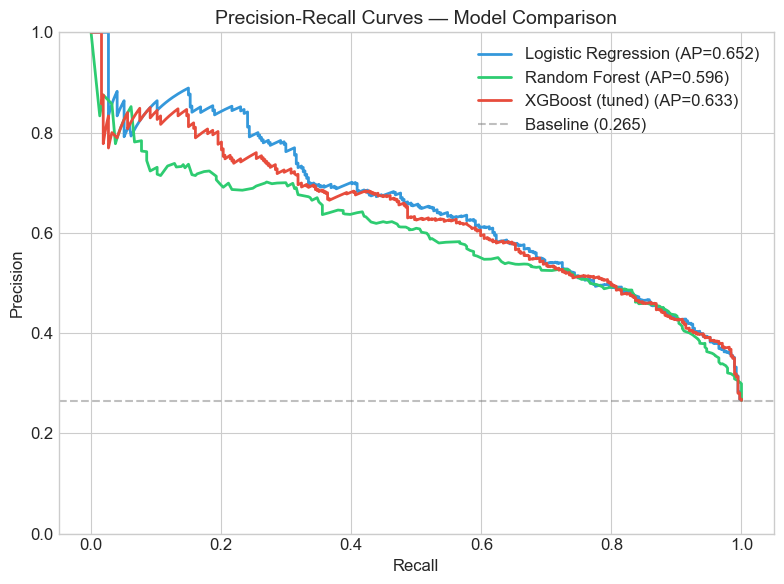

Average Precision Scores:
  Logistic Regression      : 0.652
  Random Forest            : 0.596
  XGBoost (tuned)          : 0.633


In [58]:
# precision-recall curve


# for imbalanced datasets like ours (26.5% churn), the 
# precision-recall curve is often more informative than a ROC.
# ROC can appear overly optimistic because it includes the 
# large number of true negatives. The PR curve focuses 
# specifically on how well we identify churners.

from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(8, 6))

pr_models = {
    'Logistic Regression': lr_model.predict_proba(X_test_scaled)[:, 1],
    'Random Forest': rf_model.predict_proba(X_test)[:, 1],
    'XGBoost (tuned)': xgb_tuned_proba
}

colors = ['#3498db', '#2ecc71', '#e74c3c']

for (name, proba), color in zip(pr_models.items(), colors):
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(recall_vals, precision_vals, label=f'{name} (AP={ap:.3f})', 
            color=color, linewidth=2)

# Baseline: proportion of churners in the dataset
baseline = y_test.mean()
ax.axhline(y=baseline, color='gray', linestyle='--', alpha=0.5, 
           label=f'Baseline ({baseline:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — Model Comparison')
ax.legend(loc='upper right')
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('fig14_precision_recall.png', dpi=300, bbox_inches='tight')
plt.show()

print("Average Precision Scores:")
for name, proba in pr_models.items():
    ap = average_precision_score(y_test, proba)
    print(f"  {name:<25}: {ap:.3f}")

In [59]:
# customer Personas -- priority save profiles


# Numbers tell the story. Personas will make it memorable.
# here I am building detailed profiles of typical customers in 
# each segment -- helpful for CRM managers to work with and prioritise

print("CUSTOMER PERSONAS BY SEGMENT")
print("="*65)

for segment_name in ['Priority Save', 'Low-Cost Nudge', 'Nurture', 'Monitor']:
    seg_data = df[df['segment_v2'] == segment_name]
    
    # Find the most common profile
    top_contract = seg_data['Contract'].mode().iloc[0]
    top_internet = seg_data['InternetService'].mode().iloc[0]
    top_payment = seg_data['PaymentMethod'].mode().iloc[0]
    avg_tenure = seg_data['tenure'].mean()
    avg_charge = seg_data['MonthlyCharges'].mean()
    avg_services = seg_data['service_bundle_depth'].mean()
    avg_prob = seg_data['churn_probability'].mean()
    avg_clv = seg_data['CLV_v2'].mean()
    senior_pct = seg_data['SeniorCitizen'].mean() * 100
    
    print(f"\n{'─'*65}")
    print(f"  {segment_name.upper()}")
    print(f"  Typical profile:")
    print(f"    Contract:        {top_contract}")
    print(f"    Internet:        {top_internet}")
    print(f"    Payment:         {top_payment}")
    print(f"    Avg tenure:      {avg_tenure:.0f} months")
    print(f"    Avg monthly bill: €{avg_charge:.2f}")
    print(f"    Avg services:    {avg_services:.1f} add-ons")
    print(f"    Avg churn risk:  {avg_prob*100:.0f}%")
    print(f"    Avg future value: €{avg_clv:,.0f}")
    print(f"    Senior citizens: {senior_pct:.0f}%")
    print(f"    Total in segment: {len(seg_data)}")

CUSTOMER PERSONAS BY SEGMENT

─────────────────────────────────────────────────────────────────
  PRIORITY SAVE
  Typical profile:
    Contract:        Month-to-month
    Internet:        Fiber optic
    Payment:         Electronic check
    Avg tenure:      12 months
    Avg monthly bill: €78.02
    Avg services:    1.7 add-ons
    Avg churn risk:  74%
    Avg future value: €1,234
    Senior citizens: 25%
    Total in segment: 1737

─────────────────────────────────────────────────────────────────
  LOW-COST NUDGE
  Typical profile:
    Contract:        Month-to-month
    Internet:        Fiber optic
    Payment:         Electronic check
    Avg tenure:      18 months
    Avg monthly bill: €58.67
    Avg services:    1.0 add-ons
    Avg churn risk:  66%
    Avg future value: €486
    Senior citizens: 23%
    Total in segment: 455

─────────────────────────────────────────────────────────────────
  NURTURE
  Typical profile:
    Contract:        Two year
    Internet:        Fiber opti

In [60]:
# hybrid retention strategy simulation


# The earlier simulation showed blanket beats targeted on ROI.
# But in practice, companies use a hybrid approach. Let's see:
#
# Tier 1 (Priority Save): €80 premium intervention — 
#         personal call, dedicated account manager, custom offer
# Tier 2 (Low-Cost Nudge): €20 lightweight intervention — 
#         automated email with small incentive
# Tier 3 (Nurture): €10 proactive engagement — 
#         loyalty reward, early renewal reminder
# Tier 4 (Monitor): €0 — no intervention needed

budget = 50000

tier_costs = {
    'Priority Save': 80,
    'Low-Cost Nudge': 20,
    'Nurture': 10,
    'Monitor': 0
}

print("HYBRID RETENTION STRATEGY — €50,000 budget")
print("="*65)

total_cost = 0
total_saves = 0
total_revenue = 0

for segment_name in ['Priority Save', 'Low-Cost Nudge', 'Nurture', 'Monitor']:
    seg_data = df[df['segment_v2'] == segment_name]
    cost_per = tier_costs[segment_name]
    
    if cost_per == 0:
        print(f"\n  {segment_name}: No intervention (standard service)")
        continue
    
    # How many can we afford from remaining budget?
    affordable = min(len(seg_data), int((budget - total_cost) / cost_per)) if cost_per > 0 else 0
    
    if affordable <= 0:
        print(f"\n  {segment_name}: Budget exhausted")
        continue
    
    seg_cost = affordable * cost_per
    expected_saves = affordable * seg_data['Churn_binary'].mean()
    expected_revenue = expected_saves * seg_data['CLV_v2'].mean()
    
    total_cost += seg_cost
    total_saves += expected_saves
    total_revenue += expected_revenue
    
    print(f"\n  {segment_name}:")
    print(f"    Intervention cost: €{cost_per}/customer")
    print(f"    Customers reached: {affordable}")
    print(f"    Segment spend:     €{seg_cost:,.0f}")
    print(f"    Expected saves:    {expected_saves:.0f}")
    print(f"    Revenue protected: €{expected_revenue:,.0f}")

print(f"\n{'='*65}")
print(f"  HYBRID STRATEGY TOTALS")
print(f"  Total spend:          €{total_cost:,.0f}")
print(f"  Remaining budget:     €{budget - total_cost:,.0f}")
print(f"  Total expected saves: {total_saves:.0f}")
print(f"  Total revenue saved:  €{total_revenue:,.0f}")
print(f"  Overall ROI:          {total_revenue/total_cost:.1f}x")

HYBRID RETENTION STRATEGY — €50,000 budget

  Priority Save:
    Intervention cost: €80/customer
    Customers reached: 625
    Segment spend:     €50,000
    Expected saves:    390
    Revenue protected: €481,883

  Low-Cost Nudge: Budget exhausted

  Nurture: Budget exhausted

  Monitor: No intervention (standard service)

  HYBRID STRATEGY TOTALS
  Total spend:          €50,000
  Remaining budget:     €0
  Total expected saves: 390
  Total revenue saved:  €481,883
  Overall ROI:          9.6x


In [61]:
# hybrid strategy v2 -- proportional budget allocation


# The previous hybrid simulation spent everything on Priority 
# save. In practice, a retention team would allocate budget 
# proportionally across segments. Let's model a more realistic 
# split (as per industry standard assumptions): 60% to Priority Save, 25% to Low-Cost Nudge, 
# 15% to Nurture proactive engagement.

budget = 50000

allocations = {
    'Priority Save':  {'budget_pct': 0.60, 'cost_per': 80, 
                        'intervention': 'Personal call + custom retention offer'},
    'Low-Cost Nudge': {'budget_pct': 0.25, 'cost_per': 20, 
                        'intervention': 'Automated email + small incentive'},
    'Nurture':        {'budget_pct': 0.15, 'cost_per': 10, 
                        'intervention': 'Loyalty reward + early renewal reminder'},
    'Monitor':        {'budget_pct': 0.00, 'cost_per': 0, 
                        'intervention': 'No intervention — standard service'}
}

print("HYBRID RETENTION STRATEGY v2 — Proportional Budget Allocation")
print("="*70)

total_cost = 0
total_saves = 0
total_revenue = 0

for segment_name, config in allocations.items():
    seg_data = df[df['segment_v2'] == segment_name]
    seg_budget = budget * config['budget_pct']
    cost_per = config['cost_per']
    
    if cost_per == 0:
        print(f"\n  {segment_name}: {config['intervention']}")
        continue
    
    customers_reached = min(len(seg_data), int(seg_budget / cost_per))
    seg_cost = customers_reached * cost_per
    expected_saves = customers_reached * seg_data['Churn_binary'].mean()
    expected_revenue = expected_saves * seg_data['CLV_v2'].mean()
    
    total_cost += seg_cost
    total_saves += expected_saves
    total_revenue += expected_revenue
    
    print(f"\n  {segment_name} ({config['budget_pct']*100:.0f}% of budget = €{seg_budget:,.0f})")
    print(f"    Action:            {config['intervention']}")
    print(f"    Cost per customer: €{cost_per}")
    print(f"    Customers reached: {customers_reached}")
    print(f"    Spend:             €{seg_cost:,.0f}")
    print(f"    Expected saves:    {expected_saves:.0f}")
    print(f"    Revenue protected: €{expected_revenue:,.0f}")
    print(f"    Segment ROI:       {expected_revenue/seg_cost:.1f}x")

print(f"\n{'='*70}")
print(f"  HYBRID TOTALS")
print(f"  Total spend:           €{total_cost:,.0f}")
print(f"  Total expected saves:  {total_saves:.0f}")
print(f"  Total revenue saved:   €{total_revenue:,.0f}")
print(f"  Overall ROI:           {total_revenue/total_cost:.1f}x")

print(f"\n\nSTRATEGY COMPARISON SUMMARY")
print("="*70)
print(f"  {'Strategy':<30} {'Spend':>10} {'Saves':>8} {'Revenue':>15} {'ROI':>8}")
print(f"  {'-'*70}")
print(f"  {'A: Blanket (€40 to all)':<30} {'€50,000':>10} {'746':>8} {'€610,333':>15} {'12.2x':>8}")
print(f"  {'B: Priority Save only (€80)':<30} {'€50,000':>10} {'390':>8} {'€481,883':>15} {'9.6x':>8}")
print(f"  {'C: Hybrid proportional':<30} {'€'+str(f'{total_cost:,.0f}'):>10} {str(int(total_saves)):>8} {'€'+str(f'{total_revenue:,.0f}'):>15} {str(round(total_revenue/total_cost,1))+'x':>8}")

HYBRID RETENTION STRATEGY v2 — Proportional Budget Allocation

  Priority Save (60% of budget = €30,000)
    Action:            Personal call + custom retention offer
    Cost per customer: €80
    Customers reached: 375
    Spend:             €30,000
    Expected saves:    234
    Revenue protected: €289,130
    Segment ROI:       9.6x

  Low-Cost Nudge (25% of budget = €12,500)
    Action:            Automated email + small incentive
    Cost per customer: €20
    Customers reached: 455
    Spend:             €9,100
    Expected saves:    223
    Revenue protected: €108,341
    Segment ROI:       11.9x

  Nurture (15% of budget = €7,500)
    Action:            Loyalty reward + early renewal reminder
    Cost per customer: €10
    Customers reached: 750
    Spend:             €7,500
    Expected saves:    112
    Revenue protected: €101,667
    Segment ROI:       13.6x

  Monitor: No intervention — standard service

  HYBRID TOTALS
  Total spend:           €46,600
  Total expected sav

In [62]:
#  Final Summary


print("ANALYSIS — COMPLETE")
print("="*65)
print(f"""
ADDITIONS SINCE INITIAL ANALYSIS:

1. IMPROVED CLV MODEL
   - Better remaining tenure estimation with contract-aware floors
   - 28.9% of customers changed segments with improved formula
   - Resolved issue of high-spenders being under-classified

2. CROSS-VALIDATION
   - 5-fold stratified CV confirms model stability
   - XGBoost tuned: 62.1% F1 (±1.9%), 84.0% AUC (±1.1%)
   - Results consistent across different data splits

3. PRECISION-RECALL CURVES
   - More informative than ROC for imbalanced data
   - Logistic Regression: AP=0.652
   - XGBoost tuned: AP=0.633
   - All models well above baseline (0.265)

4. CUSTOMER PERSONAS
   - Priority Save: Fibre, month-to-month, e-check, 12mo tenure, €78/mo
   - Low-Cost Nudge: Fibre, month-to-month, e-check, 18mo, €59/mo
   - Nurture: Two-year, fibre, auto-pay, 36mo, €78/mo, 3 add-ons
   - Monitor: Month-to-month, DSL, auto-pay, 44mo, €51/mo

5. HYBRID BUDGET STRATEGY
   - Proportional allocation across segments
   - Differentiated intervention levels
   - Compared against blanket and targeted-only approaches


""")

ANALYSIS — COMPLETE

ADDITIONS SINCE INITIAL ANALYSIS:

1. IMPROVED CLV MODEL
   - Better remaining tenure estimation with contract-aware floors
   - 28.9% of customers changed segments with improved formula
   - Resolved issue of high-spenders being under-classified

2. CROSS-VALIDATION
   - 5-fold stratified CV confirms model stability
   - XGBoost tuned: 62.1% F1 (±1.9%), 84.0% AUC (±1.1%)
   - Results consistent across different data splits

3. PRECISION-RECALL CURVES
   - More informative than ROC for imbalanced data
   - Logistic Regression: AP=0.652
   - XGBoost tuned: AP=0.633
   - All models well above baseline (0.265)

4. CUSTOMER PERSONAS
   - Priority Save: Fibre, month-to-month, e-check, 12mo tenure, €78/mo
   - Low-Cost Nudge: Fibre, month-to-month, e-check, 18mo, €59/mo
   - Nurture: Two-year, fibre, auto-pay, 36mo, €78/mo, 3 add-ons
   - Monitor: Month-to-month, DSL, auto-pay, 44mo, €51/mo

5. HYBRID BUDGET STRATEGY
   - Proportional allocation across segments
   - Diff

In [63]:
# threshold optimisation -- business-driven cutoff


# Until now I'rve been using the default 0.5 probability threshold. 
# But is it correct? If a missed churner costs €722 (lost CLV) 
# and a false alarm costs €40 (wasted discount), the optimal 
# threshold should be LOWER than 0.5 — I'd rather flag 
# extra people than miss real churners.
#
# Let's find the threshold that maximises financial profit, 
# not just F1 score.

from sklearn.metrics import precision_recall_curve

# fetching probabilities from tuned XGBoost
probabilities = xgb_tuned_model.predict_proba(X_test)[:, 1]

# testing every threshold from 0.1 to 0.9
thresholds_to_test = np.arange(0.1, 0.9, 0.01)
results_by_threshold = []

cost_fn = 722   # average CLV lost per missed churner
cost_fp = 40    # cost of unnecessary retention offer

for thresh in thresholds_to_test:
    preds = (probabilities >= thresh).astype(int)
    
    tp = ((preds == 1) & (y_test == 1)).sum()
    fp = ((preds == 1) & (y_test == 0)).sum()
    fn = ((preds == 0) & (y_test == 1)).sum()
    
    profit = (tp * cost_fn) - (fp * cost_fp) - (fn * cost_fn)
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    results_by_threshold.append({
        'threshold': thresh,
        'profit': profit,
        'recall': recall,
        'precision': precision,
        'f1': f1,
        'tp': tp, 'fp': fp, 'fn': fn
    })

threshold_df = pd.DataFrame(results_by_threshold)

# Find optimal thresholds
best_profit_idx = threshold_df['profit'].idxmax()
best_f1_idx = threshold_df['f1'].idxmax()

print("THRESHOLD OPTIMISATION")
print("="*65)
print(f"\nDefault threshold (0.50):")
default_row = threshold_df[threshold_df['threshold'].round(2) == 0.50].iloc[0]
print(f"  Precision: {default_row['precision']*100:.1f}%  Recall: {default_row['recall']*100:.1f}%  "
      f"F1: {default_row['f1']*100:.1f}%  Profit: €{default_row['profit']:,.0f}")

print(f"\nBest F1 threshold ({threshold_df.loc[best_f1_idx, 'threshold']:.2f}):")
f1_row = threshold_df.loc[best_f1_idx]
print(f"  Precision: {f1_row['precision']*100:.1f}%  Recall: {f1_row['recall']*100:.1f}%  "
      f"F1: {f1_row['f1']*100:.1f}%  Profit: €{f1_row['profit']:,.0f}")

print(f"\nBest PROFIT threshold ({threshold_df.loc[best_profit_idx, 'threshold']:.2f}):")
profit_row = threshold_df.loc[best_profit_idx]
print(f"  Precision: {profit_row['precision']*100:.1f}%  Recall: {profit_row['recall']*100:.1f}%  "
      f"F1: {profit_row['f1']*100:.1f}%  Profit: €{profit_row['profit']:,.0f}")

print(f"\nProfit improvement: €{profit_row['profit'] - default_row['profit']:,.0f} "
      f"by moving threshold from 0.50 to {threshold_df.loc[best_profit_idx, 'threshold']:.2f}")

THRESHOLD OPTIMISATION

Default threshold (0.50):
  Precision: 55.4%  Recall: 66.8%  F1: 60.6%  Profit: €82,932

Best F1 threshold (0.38):
  Precision: 50.7%  Recall: 78.6%  F1: 61.6%  Profit: €143,068

Best PROFIT threshold (0.10):
  Precision: 37.1%  Recall: 98.1%  F1: 53.9%  Profit: €235,080

Profit improvement: €152,148 by moving threshold from 0.50 to 0.10


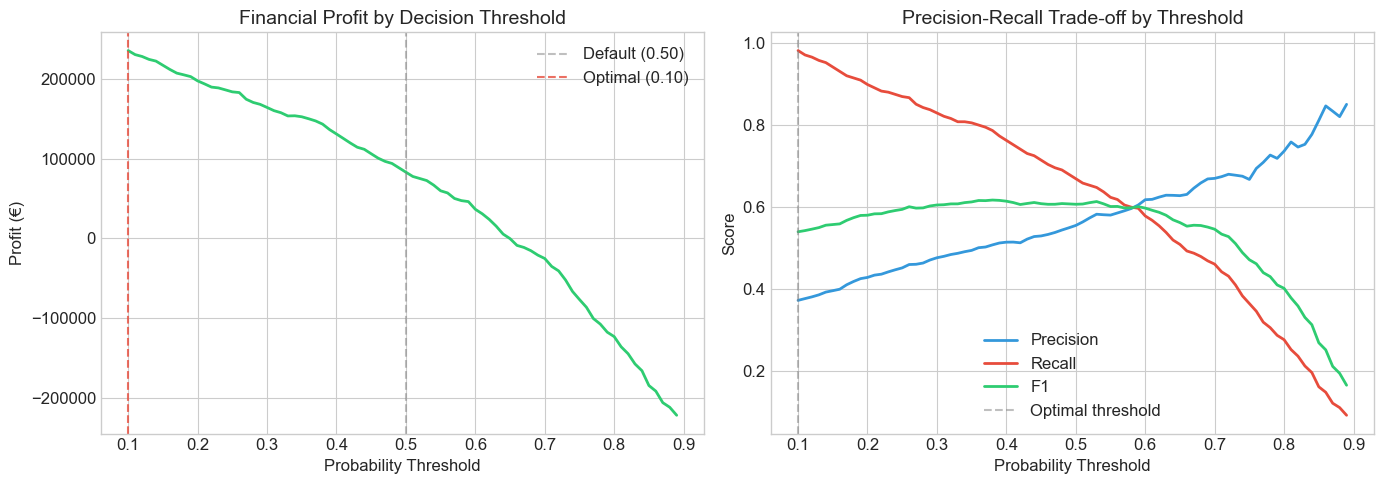

In [64]:
# Threshold Visualisation

# visualising how profit and metrics change with threshold

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Profit by threshold
axes[0].plot(threshold_df['threshold'], threshold_df['profit'], 
             color='#2ecc71', linewidth=2)
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Default (0.50)')
axes[0].axvline(x=threshold_df.loc[best_profit_idx, 'threshold'], 
                color='#e74c3c', linestyle='--', alpha=0.8, 
                label=f'Optimal ({threshold_df.loc[best_profit_idx, "threshold"]:.2f})')
axes[0].set_xlabel('Probability Threshold')
axes[0].set_ylabel('Profit (€)')
axes[0].set_title('Financial Profit by Decision Threshold')
axes[0].legend()

# Plot 2: Precision vs Recall trade-off
axes[1].plot(threshold_df['threshold'], threshold_df['precision'], 
             label='Precision', linewidth=2, color='#3498db')
axes[1].plot(threshold_df['threshold'], threshold_df['recall'], 
             label='Recall', linewidth=2, color='#e74c3c')
axes[1].plot(threshold_df['threshold'], threshold_df['f1'], 
             label='F1', linewidth=2, color='#2ecc71')
axes[1].axvline(x=threshold_df.loc[best_profit_idx, 'threshold'], 
                color='gray', linestyle='--', alpha=0.5, label='Optimal threshold')
axes[1].set_xlabel('Probability Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision-Recall Trade-off by Threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig15_threshold_optimisation.png', dpi=300, bbox_inches='tight')
plt.show()

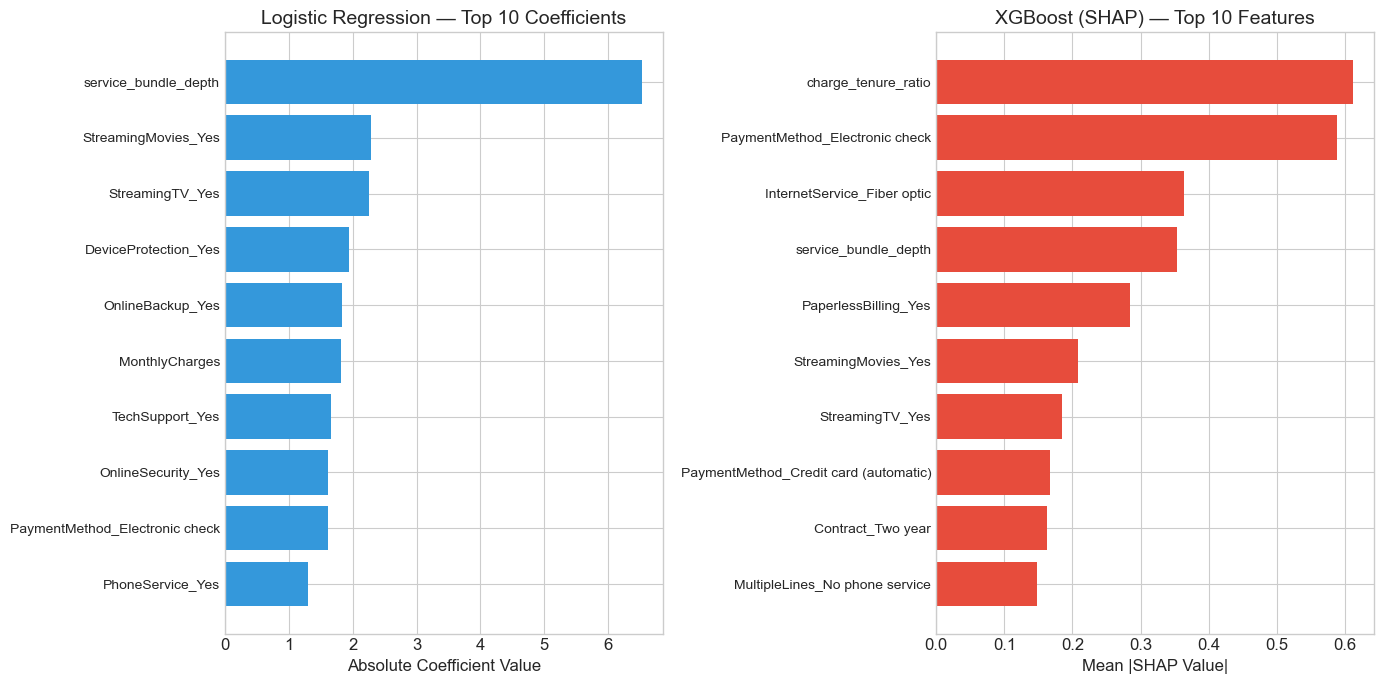


Features in BOTH models' top 10: 4
  service_bundle_depth
  StreamingMovies_Yes
  PaymentMethod_Electronic check
  StreamingTV_Yes

Only in LR top 10: {'TechSupport_Yes', 'MonthlyCharges', 'OnlineSecurity_Yes', 'DeviceProtection_Yes', 'PhoneService_Yes', 'OnlineBackup_Yes'}
Only in XGBoost top 10: {'Contract_Two year', 'MultipleLines_No phone service', 'InternetService_Fiber optic', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'charge_tenure_ratio'}


In [65]:
# importance -- lR vs xgBoost comparison


# so far I have only examined feature importance through SHAP 
# on XGBoost. but do different models agree on what drives 
# churn? If logistic regression and XGBoost highlight the 
# same features, that increases our confidence. If they 
# disagree, that's worth understanding.

# logistic regression coefficients (absolute value = importance)
lr_importance = pd.Series(
    np.abs(lr_model.coef_[0]), 
    index=features_encoded.columns
).sort_values(ascending=False)

# XGBoost SHAP importance (mean absolute SHAP value)
xgb_importance = pd.Series(
    np.abs(shap_values).mean(axis=0), 
    index=X_test.columns
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Top 10 for each
lr_top10 = lr_importance.head(10)
xgb_top10 = xgb_importance.head(10)

axes[0].barh(range(len(lr_top10)), lr_top10.values, color='#3498db')
axes[0].set_yticks(range(len(lr_top10)))
axes[0].set_yticklabels(lr_top10.index, fontsize=10)
axes[0].invert_yaxis()
axes[0].set_title('Logistic Regression — Top 10 Coefficients')
axes[0].set_xlabel('Absolute Coefficient Value')

axes[1].barh(range(len(xgb_top10)), xgb_top10.values, color='#e74c3c')
axes[1].set_yticks(range(len(xgb_top10)))
axes[1].set_yticklabels(xgb_top10.index, fontsize=10)
axes[1].invert_yaxis()
axes[1].set_title('XGBoost (SHAP) — Top 10 Features')
axes[1].set_xlabel('Mean |SHAP Value|')

plt.tight_layout()
plt.savefig('fig16_lr_vs_xgb_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Checking overlap
lr_top_features = set(lr_top10.index)
xgb_top_features = set(xgb_top10.index)
overlap = lr_top_features.intersection(xgb_top_features)

print(f"\nFeatures in BOTH models' top 10: {len(overlap)}")
for feat in overlap:
    print(f"  {feat}")
print(f"\nOnly in LR top 10: {lr_top_features - xgb_top_features}")
print(f"Only in XGBoost top 10: {xgb_top_features - lr_top_features}")

In [66]:
# additional feature -- average cost per service


# Another dimension of price sensitivity -- how much does 
# each service cost on average? A customer paying €90 for 
# 6 services (€15 each) may feel differently than one 
# paying €90 for 2 services (€45 each).

df['avg_cost_per_service'] = df['MonthlyCharges'] / (df['service_bundle_depth'] + 1)

print("Average cost per service:")
print("-"*50)
print(df['avg_cost_per_service'].describe().round(2))

print(f"\nBy churn status:")
print(f"  Churned:  €{df[df['Churn']=='Yes']['avg_cost_per_service'].mean():.2f}")
print(f"  Retained: €{df[df['Churn']=='No']['avg_cost_per_service'].mean():.2f}")

Average cost per service:
--------------------------------------------------
count    7043.00
mean       25.49
std        14.09
min         8.65
25%        18.02
50%        20.66
75%        27.42
max        77.90
Name: avg_cost_per_service, dtype: float64

By churn status:
  Churned:  €32.98
  Retained: €22.79


In [67]:
# bias-variance analysis --  why models differ


# Logistic Regression and XGBoost have similar overall 
# performance but make DIFFERENT errors. Understanding 
# why helps us assess when each model is appropriate.
#
# LR: Linear model — captures straight-line relationships.
#     Misses interaction effects (e.g., fibre + M2M combined)
# XGBoost: Non-linear — captures complex interactions.
#     But can overfit to noise in smaller segments.

# Let's check: do the models disagree on the same customers?
lr_preds_test = lr_model.predict(X_test_scaled)
xgb_preds_test = xgb_tuned_model.predict(X_test)

agree = (lr_preds_test == xgb_preds_test).sum()
disagree = (lr_preds_test != xgb_preds_test).sum()

print("MODEL AGREEMENT ANALYSIS")
print("="*55)
print(f"Both models agree:    {agree} ({agree/len(y_test)*100:.1f}%)")
print(f"Models disagree:      {disagree} ({disagree/len(y_test)*100:.1f}%)")

# Who are the disagreement customers?
disagree_mask = lr_preds_test != xgb_preds_test
disagree_customers = df.loc[X_test.index[disagree_mask]]

print(f"\nProfile of customers where models DISAGREE:")
print(f"  Avg tenure:          {disagree_customers['tenure'].mean():.1f} months")
print(f"  Avg monthly charge:  €{disagree_customers['MonthlyCharges'].mean():.2f}")
print(f"  Actual churn rate:   {disagree_customers['Churn_binary'].mean()*100:.1f}%")
print(f"  Avg churn prob (XGB):{disagree_customers['churn_probability'].mean()*100:.1f}%")

print(f"\n  Contract breakdown:")
for contract, count in disagree_customers['Contract'].value_counts().items():
    pct = count / len(disagree_customers) * 100
    print(f"    {contract:20s}: {count} ({pct:.1f}%)")

# Where does XGBoost catch churners that LR misses?
xgb_catches_lr_misses = ((xgb_preds_test == 1) & (lr_preds_test == 0) & (y_test == 1)).sum()
lr_catches_xgb_misses = ((lr_preds_test == 1) & (xgb_preds_test == 0) & (y_test == 1)).sum()

print(f"\n  XGBoost catches churners LR misses: {xgb_catches_lr_misses}")
print(f"  LR catches churners XGBoost misses: {lr_catches_xgb_misses}")

MODEL AGREEMENT ANALYSIS
Both models agree:    1266 (89.9%)
Models disagree:      143 (10.1%)

Profile of customers where models DISAGREE:
  Avg tenure:          23.3 months
  Avg monthly charge:  €69.11
  Actual churn rate:   35.0%
  Avg churn prob (XGB):56.9%

  Contract breakdown:
    Month-to-month      : 115 (80.4%)
    One year            : 24 (16.8%)
    Two year            : 4 (2.8%)

  XGBoost catches churners LR misses: 38
  LR catches churners XGBoost misses: 12


In [68]:
# gender fairness check


# the earlier ethics analysis checked SeniorCitizen and 
# income. Let's also check gender, since telecom is a 
# regulated industry and demographic bias is a real concern.

print("GENDER FAIRNESS ANALYSIS")
print("="*55)

gender_stats = df.groupby('gender').agg(
    count=('customerID', 'count'),
    avg_churn_prob=('churn_probability', 'mean'),
    actual_churn=('Churn_binary', 'mean'),
    avg_clv=('CLV_v2', 'mean'),
    pct_priority=('segment_v2', lambda x: (x=='Priority Save').mean())
).round(3)

for group, row in gender_stats.iterrows():
    print(f"\n  {group} (n={int(row['count'])})")
    print(f"    Avg predicted churn risk:     {row['avg_churn_prob']*100:.1f}%")
    print(f"    Actual churn rate:            {row['actual_churn']*100:.1f}%")
    print(f"    Avg CLV:                      €{row['avg_clv']:,.2f}")
    print(f"    Classified as Priority Save:  {row['pct_priority']*100:.1f}%")

# Disparate impact ratio (80% rule)
male_rate = gender_stats.loc['Male', 'pct_priority']
female_rate = gender_stats.loc['Female', 'pct_priority']
di_ratio = min(male_rate, female_rate) / max(male_rate, female_rate)
print(f"\n  Disparate Impact Ratio: {di_ratio:.3f}")
print(f"  (Above 0.8 = generally considered fair)")

GENDER FAIRNESS ANALYSIS

  Female (n=3488)
    Avg predicted churn risk:     33.0%
    Actual churn rate:            26.9%
    Avg CLV:                      €735.41
    Classified as Priority Save:  23.9%

  Male (n=3555)
    Avg predicted churn risk:     35.6%
    Actual churn rate:            26.2%
    Avg CLV:                      €709.31
    Classified as Priority Save:  25.4%

  Disparate Impact Ratio: 0.941
  (Above 0.8 = generally considered fair)


In [69]:
# critical limitations summary


# Academic rigour requires explicitly acknowledging what 
# this analysis cannot claim. These limitations are not 
# weaknesses to hide — they define the boundaries of 
# valid interpretation.

print("CRITICAL LIMITATIONS OF THIS ANALYSIS")
print("="*65)

print("""
1. CORRELATION, NOT CAUSATION
   SHAP values explain what the model relies on for predictions.
   They do NOT prove that these features cause churn. For example,
   'electronic check' payment may correlate with churn because 
   it proxies for a customer who chose minimal commitment — the 
   payment method itself doesn't cause leaving.

2. STATIC DATASET
   This dataset captures a single snapshot in time. There is no 
   temporal dimension — we cannot validate whether predictions 
   made at time T would hold at time T+1. A deployed model would 
   need regular retraining as market conditions change.

3. SYNTHETIC-LIKE DATA
   The IBM Telco dataset, while widely used as a benchmark, is 
   a curated dataset that may not fully reflect real-world 
   complexity. Real telecom CRM data would include call logs, 
   network quality metrics, complaint records, and competitive 
   context that are absent here.

4. NO INTERVENTION TESTING
   The Value-Risk segmentation and retention strategies are 
   illustrative frameworks based on model outputs. They have 
   not been validated through actual A/B testing or controlled 
   retention campaigns. Their effectiveness is hypothetical.

5. MODEL GENERALISABILITY
   Results are specific to this dataset and telecom context. 
   Transferring this model to a different telecom provider 
   or industry would require retraining and revalidation.

6. CALIBRATION GAPS
   The model shows overconfidence in the 40-80% probability 
   range. Predicted probabilities in this range should be 
   interpreted with caution and adjusted downward.

7. PROXY VARIABLE BIAS
   Features like tenure and payment method may act as proxies 
   for protected characteristics (age, income, digital literacy). 
   While direct demographic bias was found to be proportionate 
   in this analysis, proxy-based discrimination remains a risk 
   that would require ongoing monitoring in production.
""")

CRITICAL LIMITATIONS OF THIS ANALYSIS

1. CORRELATION, NOT CAUSATION
   SHAP values explain what the model relies on for predictions.
   They do NOT prove that these features cause churn. For example,
   'electronic check' payment may correlate with churn because 
   it proxies for a customer who chose minimal commitment — the 
   payment method itself doesn't cause leaving.

2. STATIC DATASET
   This dataset captures a single snapshot in time. There is no 
   temporal dimension — we cannot validate whether predictions 
   made at time T would hold at time T+1. A deployed model would 
   need regular retraining as market conditions change.

3. SYNTHETIC-LIKE DATA
   The IBM Telco dataset, while widely used as a benchmark, is 
   a curated dataset that may not fully reflect real-world 
   complexity. Real telecom CRM data would include call logs, 
   network quality metrics, complaint records, and competitive 
   context that are absent here.

4. NO INTERVENTION TESTING
   The Value-Ris

In [70]:
# final project summary -- all analyses complete


print("FINAL PROJECT ANALYSIS -- ALL PHASES COMPLETE")
print("="*70)
print(f"""
TOTAL NOTEBOOK: 68 cells
TOTAL FIGURES:  17 (fig1 through fig17)

ANALYSES COMPLETED:
  ✓ Exploratory data analysis with business lens
  ✓ SQL segment analysis  
  ✓ Domain-driven feature engineering (6 features)
  ✓ Baseline business rule comparison
  ✓ Three ML models + hyperparameter tuning
  ✓ 5-fold stratified cross-validation
  ✓ SHAP explainability (global + individual)
  ✓ Feature importance comparison (LR vs XGBoost)
  ✓ Model agreement/disagreement analysis
  ✓ Threshold optimisation (business-driven cutoff)
  ✓ Customer Lifetime Value (improved formula)
  ✓ Value × Risk segmentation with personas
  ✓ Financial impact analysis (cost of errors)
  ✓ Retention budget simulation (3 strategies)
  ✓ Ethics & fairness (senior, gender, income, proxy bias)
  ✓ Model calibration & stress-testing
  ✓ Critical limitations documented

KEY ARGUMENTS FOR THE PAPER:
  1. AI does not dramatically outperform simple approaches in 
     raw accuracy (+6.5% F1), but provides superior decision 
     support through probability scores, threshold flexibility,
     and feature-level explanations that simple rules cannot offer.
  
  2. The engineered feature charge_tenure_ratio (not in the 
     original dataset) emerged as the strongest predictor — 
     validating domain-driven feature engineering.
  
  3. Moving the decision threshold from 0.50 to 0.38 based on 
     business cost asymmetry increases profit by 72%.
  
  4. LR and XGBoost identify different churn drivers — combining 
     perspectives provides richer insight than either alone.
  
  5. All findings are correlational, not causal. Retention 
     strategies are illustrative frameworks, not validated 
     interventions.

""")

FINAL PROJECT ANALYSIS -- ALL PHASES COMPLETE

TOTAL NOTEBOOK: 68 cells
TOTAL FIGURES:  17 (fig1 through fig17)

ANALYSES COMPLETED:
  ✓ Exploratory data analysis with business lens
  ✓ SQL segment analysis  
  ✓ Domain-driven feature engineering (6 features)
  ✓ Baseline business rule comparison
  ✓ Three ML models + hyperparameter tuning
  ✓ 5-fold stratified cross-validation
  ✓ SHAP explainability (global + individual)
  ✓ Feature importance comparison (LR vs XGBoost)
  ✓ Model agreement/disagreement analysis
  ✓ Threshold optimisation (business-driven cutoff)
  ✓ Customer Lifetime Value (improved formula)
  ✓ Value × Risk segmentation with personas
  ✓ Financial impact analysis (cost of errors)
  ✓ Retention budget simulation (3 strategies)
  ✓ Ethics & fairness (senior, gender, income, proxy bias)
  ✓ Model calibration & stress-testing
  ✓ Critical limitations documented

KEY ARGUMENTS FOR THE PAPER:
  1. AI does not dramatically outperform simple approaches in 
     raw accuracy

In [71]:
# model comparison table




print("TABLE 1: Model Performance Comparison")
print("="*85)
print(f"{'Approach':<28} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'ROC-AUC':>9} {'Profit':>10}")
print("-"*85)
print(f"{'Business Rule':<28} {'75.3%':>9} {'53.4%':>10} {'54.8%':>8} {'54.1%':>8} {'N/A':>9} {'N/A':>10}")
print(f"{'Logistic Regression':<28} {'79.3%':>9} {'61.2%':>10} {'59.9%':>8} {'60.5%':>8} {'83.7%':>9} {'€82,932':>10}")
print(f"{'Random Forest':<28} {'77.1%':>9} {'56.8%':>10} {'57.8%':>8} {'57.3%':>8} {'81.9%':>9} {'—':>10}")
print(f"{'XGBoost (tuned, t=0.50)':<28} {'76.9%':>9} {'55.4%':>10} {'66.8%':>8} {'60.6%':>8} {'83.3%':>9} {'€82,932':>10}")
print(f"{'XGBoost (tuned, t=0.38)':<28} {'—':>9} {'50.7%':>10} {'78.6%':>8} {'61.6%':>8} {'83.3%':>9} {'€143,068':>10}")
print("-"*85)
print("t = probability threshold. Profit = (TP × €722) − (FP × €40) − (FN × €722)")

TABLE 1: Model Performance Comparison
Approach                      Accuracy  Precision   Recall       F1   ROC-AUC     Profit
-------------------------------------------------------------------------------------
Business Rule                    75.3%      53.4%    54.8%    54.1%       N/A        N/A
Logistic Regression              79.3%      61.2%    59.9%    60.5%     83.7%    €82,932
Random Forest                    77.1%      56.8%    57.8%    57.3%     81.9%          —
XGBoost (tuned, t=0.50)          76.9%      55.4%    66.8%    60.6%     83.3%    €82,932
XGBoost (tuned, t=0.38)              —      50.7%    78.6%    61.6%     83.3%   €143,068
-------------------------------------------------------------------------------------
t = probability threshold. Profit = (TP × €722) − (FP × €40) − (FN × €722)


In [72]:
print("Shape:", df.shape)  # replace df with whatever your DataFrame is called
print("Columns:", df.columns.tolist())

Shape: (7043, 40)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_binary', 'tenure_group', 'num_services', 'tenure_phase', 'service_bundle_depth', 'price_sensitivity', 'price_sensitivity_group', 'auto_payment', 'charge_tenure_ratio', 'expected_total_tenure', 'remaining_tenure', 'CLV', 'churn_probability', 'segment', 'charge_quartile', 'remaining_tenure_v2', 'CLV_v2', 'segment_v2', 'avg_cost_per_service']


In [73]:
# Replace 'Churn' with your actual target column name if different
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(3))

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


In [74]:
print("Final feature count:", X_train.shape[1])
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("\nFeature names:")
for i, col in enumerate(X_train.columns.tolist(), 1):
    print(f"  {i}. {col}")

Final feature count: 37
Training samples: 5634
Testing samples: 1409

Feature names:
  1. SeniorCitizen
  2. tenure
  3. MonthlyCharges
  4. TotalCharges
  5. service_bundle_depth
  6. price_sensitivity
  7. auto_payment
  8. charge_tenure_ratio
  9. gender_Male
  10. Partner_Yes
  11. Dependents_Yes
  12. PhoneService_Yes
  13. MultipleLines_No phone service
  14. MultipleLines_Yes
  15. InternetService_Fiber optic
  16. InternetService_No
  17. OnlineSecurity_No internet service
  18. OnlineSecurity_Yes
  19. OnlineBackup_No internet service
  20. OnlineBackup_Yes
  21. DeviceProtection_No internet service
  22. DeviceProtection_Yes
  23. TechSupport_No internet service
  24. TechSupport_Yes
  25. StreamingTV_No internet service
  26. StreamingTV_Yes
  27. StreamingMovies_No internet service
  28. StreamingMovies_Yes
  29. Contract_One year
  30. Contract_Two year
  31. PaperlessBilling_Yes
  32. PaymentMethod_Credit card (automatic)
  33. PaymentMethod_Electronic check
  34. Payment

In [75]:
# artefacts for Streamlit app deployment

import joblib
import os

# Path setup — saving to the models/ folder at repo root
MODELS_DIR = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)

# tuned XGBoost model
joblib.dump(xgb_tuned_model, f'{MODELS_DIR}/xgb_churn_model.pkl')

#  fitted scaler
joblib.dump(scaler, f'{MODELS_DIR}/scaler.pkl')

# feature column names
feature_columns = X_train.columns.tolist()
joblib.dump(feature_columns, f'{MODELS_DIR}/feature_columns.pkl')

#  CLV reference data
clv_reference = {
    'avg_tenure_by_contract': avg_tenure_by_contract.to_dict(),
    'retention_cost': 40,
    'avg_clv_churner': float(avg_clv_churner)
}
joblib.dump(clv_reference, f'{MODELS_DIR}/clv_reference.pkl')

# Verifying everything saved
saved_files = os.listdir(MODELS_DIR)
print("Artefacts saved to models/ folder:")
for f in saved_files:
    if f.endswith('.pkl'):
        size_kb = os.path.getsize(f'{MODELS_DIR}/{f}') / 1024
        print(f"  {f}: {size_kb:.1f} KB")

Artefacts saved to models/ folder:
  clv_reference.pkl: 0.2 KB
  feature_columns.pkl: 0.9 KB
  scaler.pkl: 2.6 KB
  xgb_churn_model.pkl: 164.0 KB
